# **Data Visualization Final Project**

Group member: Haoxuan Lu, Joey Zhu, Yijia Liu, Siyi Zhou

Date: Apr 20, 2026

## **Project Overview**

This project, **Street-Level Stories: An Interactive Visual Analysis of NYC Arrest Patterns**, investigates public safety trends across New York City using the **NYPD Arrest Data (Year to Date)** dataset from NYC Open Data. The dataset contains detailed records of arrests made across all five boroughs, including arrest dates, offense descriptions, legal classifications, precinct locations, demographic information, and geographic coordinates. By transforming this large-scale administrative dataset into clear visual narratives, the project aims to uncover how crime and enforcement patterns vary across space, time, and population groups.

Our analysis combines traditional statistical summaries with modern data visualization techniques. Core questions include: How do arrests fluctuate over time across boroughs? Which offense categories dominate specific neighborhoods? How do arrest patterns differ by age, sex, or race? Are there recurring temporal patterns by weekday or hour? In addition, geospatial mapping will reveal hotspots and precinct-level concentration, while advanced analytics such as text mining and network analysis will explore latent structures in offense descriptions and similarities between precincts.

The final deliverable will be an interactive **Streamlit dashboard** supported by publication-quality static charts. Users will be able to filter by borough, offense type, legal severity, demographic groups, and time period to dynamically explore the data. Specialized views such as choropleth maps, hotspot density maps, and comparative borough dashboards will help turn raw records into actionable insights for policymakers, researchers, and the public.

From a technical perspective, the workflow emphasizes reproducible data engineering and scalable analytics. Raw data will be cleaned, standardized, and converted into a master dataset for downstream team use. Aggregated summary tables and cached files will improve performance, ensuring that complex visualizations load efficiently. This project demonstrates how thoughtful data wrangling, visual design, and analytical storytelling can make civic datasets both accessible and meaningful.


## **Pre-Code Project Setup**

### **1. Data Source and Scope**

This project uses the **New York City Open Data NYPD Arrest Data (Year to Date)** dataset, an official public dataset released by the **New York Police Department**. The file contains arrest records reported during the current calendar year and is updated periodically. Each row in the dataset represents one individual arrest event, making the dataset suitable for analyzing law enforcement activity, spatial concentration, temporal trends, and demographic patterns across **New York City**.

### **2. Dataset Metadata and Variable Structure**

The dataset includes multiple dimensions of information that support rich exploratory analysis:

* **Record Identifier**

  * `ARREST_KEY`: Unique identifier for each arrest record

* **Temporal Variables**

  * `ARREST_DATE`: Date of arrest

* **Offense and Legal Variables**

  * `PD_CD`: Internal police offense code
  * `PD_DESC`: Detailed offense description
  * `KY_CD`: Broad offense classification code
  * `OFNS_DESC`: Major offense category
  * `LAW_CODE`: Penal law section
  * `LAW_CAT_CD`: Offense severity (`F` = Felony, `M` = Misdemeanor, `V` = Violation)

* **Spatial Variables**

  * `ARREST_BORO`: Borough of arrest
  * `ARREST_PRECINCT`: Precinct number
  * `X_COORD_CD`, `Y_COORD_CD`: NYC projected coordinates
  * `Latitude`, `Longitude`: Geographic coordinates
  * `Location`: Combined spatial point field

* **Demographic Variables**

  * `AGE_GROUP`: Age category of arrested individual
  * `PERP_SEX`: Sex
  * `PERP_RACE`: Race / ethnicity classification

* **Administrative Variable**

  * `JURISDICTION_CODE`: Enforcement jurisdiction code

### **3. Data Cleaning and Preparation Objectives**

Before visualization and modeling, the raw dataset must be cleaned and standardized. The coding workflow will focus on:

* converting date fields into proper datetime format
* checking missing values across key columns
* identifying duplicate records
* validating categorical labels and borough codes
* standardizing offense and demographic labels where needed
* detecting invalid or missing coordinates
* creating derived time variables (month, weekday, hour if available)
* exporting a clean master dataset for team-wide use

### **4. Data Quality Considerations**

Several limitations should be acknowledged before analysis:

* Some records may contain missing or imprecise latitude/longitude values
* Borough and legal category fields may use abbreviated coding systems
* Year-to-date data reflects only the current reporting period, not historical long-term trends
* Arrest records represent police enforcement activity, not total crime incidence
* Demographic categories are administrative classifications and may contain inconsistencies

### **5. Analytical Value of the Dataset**

This dataset is especially valuable because it combines **time, location, offense type, and demographic information** in a single structured table. After cleaning, it can support:

* borough and precinct comparisons
* arrest trend analysis over time
* demographic breakdowns of enforcement patterns
* offense composition analysis
* hotspot and geospatial mapping
* advanced text and network analysis on offense descriptions


##**Part 1: Data Cleaning & Preprocessing**

In [ ]:
# =====================================================
# 1. Import Necessary Libraries
# =====================================================

import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import altair as alt

# Utility
import warnings
warnings.filterwarnings("ignore")

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 1200)

# Plot style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

print("Libraries imported successfully.")

Libraries imported successfully.


In [ ]:
# =====================================================
# 2. Upload / Load Dataset
# =====================================================

df = pd.read_csv("NYPD_Arrest_Data_(Year_to_Date)_20260419.csv", engine='python', on_bad_lines='skip')

# Preview shape
print("Dataset loaded successfully.")
print("Rows, Columns:", df.shape)

Dataset loaded successfully.
Rows, Columns: (278953, 19)


In [ ]:
df.head()

,ARREST_KEY,ARREST_DATE,PD_CD,PD_DESC,KY_CD,OFNS_DESC,LAW_CODE,LAW_CAT_CD,ARREST_BORO,ARREST_PRECINCT,JURISDICTION_CODE,AGE_GROUP,PERP_SEX,PERP_RACE,X_COORD_CD,Y_COORD_CD,Latitude,Longitude,Location
0,299201470,01/10/2025,105,STRANGULATION 1ST,106.0,FELONY ASSAULT,PL 1211200,F,Q,110,0,25-44,F,WHITE,1017105,210917,40.745543,-73.881427,POINT (-73.881427 40.745543)
1,299351927,01/13/2025,105,STRANGULATION 1ST,106.0,FELONY ASSAULT,PL 1211200,F,S,120,0,25-44,M,BLACK,962808,174275,40.645005,-74.077265,POINT (-74.077265 40.645005)
2,299366743,01/13/2025,157,RAPE 1,104.0,RAPE,PL 130351A,F,B,46,0,25-44,M,BLACK HISPANIC,1011755,250279,40.853598,-73.900577,POINT (-73.9005768807295 40.8535983673823)
3,300990163,02/12/2025,153,RAPE 3,104.0,RAPE,PL 1302504,F,K,77,0,(null),(null),BLACK,1003509,185018,40.674496,-73.930571,POINT (-73.9305713255961 40.6744956865259)
4,301010124,02/12/2025,157,RAPE 1,104.0,RAPE,PL 130353A,F,K,77,0,25-44,M,BLACK,1003509,185018,40.674496,-73.930571,POINT (-73.9305713255961 40.6744956865259)


In [ ]:
# =====================================================
# 4. Convert Date Field to Proper Datetime Format
# =====================================================

df["ARREST_DATE"] = pd.to_datetime(df["ARREST_DATE"], errors="coerce")

print("ARREST_DATE converted to datetime.")
print(df["ARREST_DATE"].dtype)
print("Invalid dates:", df["ARREST_DATE"].isna().sum())

ARREST_DATE converted to datetime.
datetime64[ns]
Invalid dates: 0


In [ ]:
# =====================================================
# 5. Check Missing Values Across Key Columns
# =====================================================

key_columns = [
    "ARREST_KEY", "ARREST_DATE", "PD_DESC", "OFNS_DESC", "LAW_CAT_CD",
    "ARREST_BORO", "ARREST_PRECINCT", "AGE_GROUP", "PERP_SEX",
    "PERP_RACE", "Latitude", "Longitude"
]

missing_summary = (
    df[key_columns]
    .isna()
    .sum()
    .reset_index()
)

missing_summary.columns = ["column", "missing_count"]
missing_summary["missing_pct"] = (missing_summary["missing_count"] / len(df) * 100).round(2)

missing_summary.sort_values("missing_count", ascending=False)

,column,missing_count,missing_pct
4,LAW_CAT_CD,1474,0.53
0,ARREST_KEY,0,0.00
2,PD_DESC,0,0.00
1,ARREST_DATE,0,0.00
3,OFNS_DESC,0,0.00
5,ARREST_BORO,0,0.00
6,ARREST_PRECINCT,0,0.00
7,AGE_GROUP,0,0.00
8,PERP_SEX,0,0.00
9,PERP_RACE,0,0.00


In [ ]:
# =====================================================
# 6. Identify Duplicate Records
# =====================================================

# Full-row duplicates
full_duplicates = df.duplicated().sum()

# Duplicates based on arrest key
key_duplicates = df["ARREST_KEY"].duplicated().sum()

print("Full-row duplicates:", full_duplicates)
print("ARREST_KEY duplicates:", key_duplicates)

Full-row duplicates: 0
ARREST_KEY duplicates: 0


In [ ]:
# =====================================================
# 7. Validate Categorical Labels and Borough Codes
# =====================================================

print("Unique borough codes:")
print(sorted(df["ARREST_BORO"].dropna().unique()))

print("\nUnique law category codes:")
print(sorted(df["LAW_CAT_CD"].dropna().unique()))

print("\nUnique sex codes:")
print(sorted(df["PERP_SEX"].dropna().unique()))

print("\nSample age groups:")
print(sorted(df["AGE_GROUP"].dropna().unique()))

Unique borough codes:
['B', 'K', 'M', 'Q', 'S']

Unique law category codes:
['9', 'F', 'I', 'M', 'V']

Unique sex codes:
['(null)', 'F', 'M']

Sample age groups:
['(null)', '18-24', '25-44', '45-64', '65+', '<18']


In [ ]:
# =====================================================
# 8. Standardize Borough, Law Category, and Demographic Labels
# =====================================================

df_clean = df.copy()

# Standardize text formatting first
text_cols = ["ARREST_BORO", "LAW_CAT_CD", "AGE_GROUP", "PERP_SEX", "PERP_RACE", "PD_DESC", "OFNS_DESC"]
for col in text_cols:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].astype(str).str.strip()

# Replace common string versions of missing values with np.nan
df_clean = df_clean.replace({
    "": np.nan,
    "nan": np.nan,
    "NaN": np.nan,
    "UNKNOWN": np.nan,
    "UNSPECIFIED": np.nan
})

# Borough mapping
boro_map = {
    "B": "Bronx",
    "K": "Brooklyn",
    "M": "Manhattan",
    "Q": "Queens",
    "S": "Staten Island"
}
df_clean["ARREST_BORO"] = df_clean["ARREST_BORO"].replace(boro_map)

# Law category mapping
law_map = {
    "F": "Felony",
    "M": "Misdemeanor",
    "V": "Violation",
    "I": "Infraction"
}
df_clean["LAW_CAT_CD"] = df_clean["LAW_CAT_CD"].replace(law_map)

# Sex mapping
sex_map = {
    "M": "Male",
    "F": "Female",
    "U": "Unknown"
}
df_clean["PERP_SEX"] = df_clean["PERP_SEX"].replace(sex_map)

print("Label standardization complete.")
df_clean[["ARREST_BORO", "LAW_CAT_CD", "PERP_SEX"]].head()

Label standardization complete.


,ARREST_BORO,LAW_CAT_CD,PERP_SEX
0,Queens,Felony,Female
1,Staten Island,Felony,Male
2,Bronx,Felony,Male
3,Brooklyn,Felony,(null)
4,Brooklyn,Felony,Male


In [ ]:
# =====================================================
# 9. Detect Invalid or Missing Coordinates
# =====================================================

# Convert coordinates to numeric in case they were read as object
df_clean["Latitude"] = pd.to_numeric(df_clean["Latitude"], errors="coerce")
df_clean["Longitude"] = pd.to_numeric(df_clean["Longitude"], errors="coerce")

# NYC approximate bounding box check
valid_lat = df_clean["Latitude"].between(40.45, 40.95, inclusive="both")
valid_lon = df_clean["Longitude"].between(-74.30, -73.65, inclusive="both")

df_clean["coord_missing"] = df_clean["Latitude"].isna() | df_clean["Longitude"].isna()
df_clean["coord_invalid"] = ~(valid_lat & valid_lon) & ~df_clean["coord_missing"]

print("Missing coordinates:", df_clean["coord_missing"].sum())
print("Invalid coordinates:", df_clean["coord_invalid"].sum())

Missing coordinates: 0
Invalid coordinates: 0


In [ ]:
# =====================================================
# 10. Inspect Records with Invalid Coordinates
# =====================================================

invalid_coord_rows = df_clean[df_clean["coord_invalid"] == True][
    ["ARREST_KEY", "ARREST_BORO", "ARREST_PRECINCT", "Latitude", "Longitude"]
]

invalid_coord_rows.head(20)

,ARREST_KEY,ARREST_BORO,ARREST_PRECINCT,Latitude,Longitude


In [ ]:
# =====================================================
# 11. Create Derived Time Variables
# =====================================================

df_clean["year"] = df_clean["ARREST_DATE"].dt.year
df_clean["month"] = df_clean["ARREST_DATE"].dt.month
df_clean["month_name"] = df_clean["ARREST_DATE"].dt.month_name()
df_clean["day"] = df_clean["ARREST_DATE"].dt.day
df_clean["weekday"] = df_clean["ARREST_DATE"].dt.day_name()
df_clean["week_of_year"] = df_clean["ARREST_DATE"].dt.isocalendar().week.astype("Int64")
df_clean["quarter"] = df_clean["ARREST_DATE"].dt.quarter

print("Derived date variables created.")
df_clean[["ARREST_DATE", "year", "month", "month_name", "weekday", "quarter"]].head()

Derived date variables created.


,ARREST_DATE,year,month,month_name,weekday,quarter
0,2025-01-10,2025,1,January,Friday,1
1,2025-01-13,2025,1,January,Monday,1
2,2025-01-13,2025,1,January,Monday,1
3,2025-02-12,2025,2,February,Wednesday,1
4,2025-02-12,2025,2,February,Wednesday,1


In [ ]:
# =====================================================
# 12. Create Hour Variable if ARREST_TIME Exists
# =====================================================

if "ARREST_TIME" in df_clean.columns:
    df_clean["ARREST_TIME"] = pd.to_datetime(df_clean["ARREST_TIME"], format="%H:%M:%S", errors="coerce")
    df_clean["hour"] = df_clean["ARREST_TIME"].dt.hour
    print("Hour variable created from ARREST_TIME.")
    display(df_clean[["ARREST_TIME", "hour"]].head())
else:
    print("ARREST_TIME column not found, so no hour variable was created.")

ARREST_TIME column not found, so no hour variable was created.


In [ ]:
# =====================================================
# 13. Remove Duplicate Records by ARREST_KEY
# =====================================================

before_rows = len(df_clean)

df_clean = df_clean.drop_duplicates(subset=["ARREST_KEY"]).copy()

after_rows = len(df_clean)

print("Rows before duplicate removal:", before_rows)
print("Rows after duplicate removal:", after_rows)
print("Duplicates removed:", before_rows - after_rows)

Rows before duplicate removal: 278953
Rows after duplicate removal: 278953
Duplicates removed: 0


In [ ]:
# =====================================================
# 14. Drop Rows with Missing Values in Key Columns
# =====================================================

# Columns required for analysis
required_cols = [
    "ARREST_KEY",
    "ARREST_DATE",
    "PD_DESC",
    "OFNS_DESC",
    "LAW_CAT_CD",
    "ARREST_BORO",
    "ARREST_PRECINCT",
    "AGE_GROUP",
    "PERP_SEX",
    "PERP_RACE",
    "Latitude",
    "Longitude"
]

before_drop = len(df_clean)

# Drop rows with any missing values in required columns
df_clean = df_clean.dropna(subset=required_cols).copy()

after_drop = len(df_clean)

print("Rows before dropping missing values:", before_drop)
print("Rows after dropping missing values:", after_drop)
print("Rows removed:", before_drop - after_drop)

Rows before dropping missing values: 278953
Rows after dropping missing values: 276541
Rows removed: 2412


In [ ]:
# =====================================================
# 15. Confirm No Missing Values Remain
# =====================================================

df_clean[required_cols].isna().sum()

,0
ARREST_KEY,0
ARREST_DATE,0
PD_DESC,0
OFNS_DESC,0
LAW_CAT_CD,0
ARREST_BORO,0
ARREST_PRECINCT,0
AGE_GROUP,0
PERP_SEX,0
PERP_RACE,0


In [ ]:
# =====================================================
# 16. Updated Data Quality Summary
# =====================================================

quality_summary = pd.DataFrame({
    "Metric": [
        "Final Rows",
        "Final Columns",
        "Duplicate Rows Removed",
        "Rows Removed for Missing Values",
        "Invalid Coordinates Remaining"
    ],
    "Value": [
        len(df_clean),
        df_clean.shape[1],
        before_rows - after_rows,
        before_drop - after_drop,
        df_clean["coord_invalid"].sum()
    ]
})

quality_summary

,Metric,Value
0,Final Rows,276541
1,Final Columns,28
2,Duplicate Rows Removed,0
3,Rows Removed for Missing Values,2412
4,Invalid Coordinates Remaining,0


In [ ]:
# =====================================================
# 17. Export Final Clean Dataset
# =====================================================

df_clean.to_parquet("master.parquet", index=False)
df_clean.to_csv("master_cleaned.csv", index=False)

print("Final cleaned dataset exported successfully.")
df_clean.head()

Final cleaned dataset exported successfully.


,ARREST_KEY,ARREST_DATE,PD_CD,PD_DESC,KY_CD,OFNS_DESC,LAW_CODE,LAW_CAT_CD,ARREST_BORO,ARREST_PRECINCT,JURISDICTION_CODE,AGE_GROUP,PERP_SEX,PERP_RACE,X_COORD_CD,Y_COORD_CD,Latitude,Longitude,Location,coord_missing,coord_invalid,year,month,month_name,day,weekday,week_of_year,quarter
0,299201470,2025-01-10,105,STRANGULATION 1ST,106.0,FELONY ASSAULT,PL 1211200,Felony,Queens,110,0,25-44,Female,WHITE,1017105,210917,40.745543,-73.881427,POINT (-73.881427 40.745543),False,False,2025,1,January,10,Friday,2,1
1,299351927,2025-01-13,105,STRANGULATION 1ST,106.0,FELONY ASSAULT,PL 1211200,Felony,Staten Island,120,0,25-44,Male,BLACK,962808,174275,40.645005,-74.077265,POINT (-74.077265 40.645005),False,False,2025,1,January,13,Monday,3,1
2,299366743,2025-01-13,157,RAPE 1,104.0,RAPE,PL 130351A,Felony,Bronx,46,0,25-44,Male,BLACK HISPANIC,1011755,250279,40.853598,-73.900577,POINT (-73.9005768807295 40.8535983673823),False,False,2025,1,January,13,Monday,3,1
3,300990163,2025-02-12,153,RAPE 3,104.0,RAPE,PL 1302504,Felony,Brooklyn,77,0,(null),(null),BLACK,1003509,185018,40.674496,-73.930571,POINT (-73.9305713255961 40.6744956865259),False,False,2025,2,February,12,Wednesday,7,1
4,301010124,2025-02-12,157,RAPE 1,104.0,RAPE,PL 130353A,Felony,Brooklyn,77,0,25-44,Male,BLACK,1003509,185018,40.674496,-73.930571,POINT (-73.9305713255961 40.6744956865259),False,False,2025,2,February,12,Wednesday,7,1


### **Exploratory Data Analysis & Descriptive Analysis**

In [ ]:
# =====================================================
# Basic EDA 1: Dataset Shape and Column Names
# =====================================================

print("Rows, Columns:", df_clean.shape)
print("\nColumns:")
print(df_clean.columns.tolist())

Rows, Columns: (276541, 28)

Columns:
['ARREST_KEY', 'ARREST_DATE', 'PD_CD', 'PD_DESC', 'KY_CD', 'OFNS_DESC', 'LAW_CODE', 'LAW_CAT_CD', 'ARREST_BORO', 'ARREST_PRECINCT', 'JURISDICTION_CODE', 'AGE_GROUP', 'PERP_SEX', 'PERP_RACE', 'X_COORD_CD', 'Y_COORD_CD', 'Latitude', 'Longitude', 'Location', 'coord_missing', 'coord_invalid', 'year', 'month', 'month_name', 'day', 'weekday', 'week_of_year', 'quarter']


In [ ]:
# =====================================================
# Basic EDA 2: Preview First Five Rows
# =====================================================

df_clean.head()

,ARREST_KEY,ARREST_DATE,PD_CD,PD_DESC,KY_CD,OFNS_DESC,LAW_CODE,LAW_CAT_CD,ARREST_BORO,ARREST_PRECINCT,JURISDICTION_CODE,AGE_GROUP,PERP_SEX,PERP_RACE,X_COORD_CD,Y_COORD_CD,Latitude,Longitude,Location,coord_missing,coord_invalid,year,month,month_name,day,weekday,week_of_year,quarter
0,299201470,2025-01-10,105,STRANGULATION 1ST,106.0,FELONY ASSAULT,PL 1211200,Felony,Queens,110,0,25-44,Female,WHITE,1017105,210917,40.745543,-73.881427,POINT (-73.881427 40.745543),False,False,2025,1,January,10,Friday,2,1
1,299351927,2025-01-13,105,STRANGULATION 1ST,106.0,FELONY ASSAULT,PL 1211200,Felony,Staten Island,120,0,25-44,Male,BLACK,962808,174275,40.645005,-74.077265,POINT (-74.077265 40.645005),False,False,2025,1,January,13,Monday,3,1
2,299366743,2025-01-13,157,RAPE 1,104.0,RAPE,PL 130351A,Felony,Bronx,46,0,25-44,Male,BLACK HISPANIC,1011755,250279,40.853598,-73.900577,POINT (-73.9005768807295 40.8535983673823),False,False,2025,1,January,13,Monday,3,1
3,300990163,2025-02-12,153,RAPE 3,104.0,RAPE,PL 1302504,Felony,Brooklyn,77,0,(null),(null),BLACK,1003509,185018,40.674496,-73.930571,POINT (-73.9305713255961 40.6744956865259),False,False,2025,2,February,12,Wednesday,7,1
4,301010124,2025-02-12,157,RAPE 1,104.0,RAPE,PL 130353A,Felony,Brooklyn,77,0,25-44,Male,BLACK,1003509,185018,40.674496,-73.930571,POINT (-73.9305713255961 40.6744956865259),False,False,2025,2,February,12,Wednesday,7,1


In [ ]:
# =====================================================
# Basic EDA 3: Missing Values Check
# =====================================================

df_clean.isna().sum().sort_values(ascending=False).head(15)

,0
KY_CD,23
ARREST_KEY,0
PD_CD,0
ARREST_DATE,0
PD_DESC,0
OFNS_DESC,0
LAW_CODE,0
LAW_CAT_CD,0
ARREST_BORO,0
ARREST_PRECINCT,0


In [ ]:
# =====================================================
# Basic EDA 4: Summary Statistics (Numeric Columns)
# =====================================================

df_clean.describe().T

,count,mean,min,25%,50%,75%,max,std
ARREST_KEY,276541.0,308567272.791196,298704329.0,303844930.0,308606998.0,313493653.0,318224439.0,5663090.946094
ARREST_DATE,276541,2025-06-27 05:08:57.160131584,2025-01-01 00:00:00,2025-03-29 00:00:00,2025-06-25 00:00:00,2025-09-25 00:00:00,2025-12-31 00:00:00,NaN
PD_CD,276541.0,445.680037,100.0,175.0,439.0,724.0,997.0,273.716477
KY_CD,276518.0,254.943128,101.0,117.0,341.0,344.0,882.0,138.712607
ARREST_PRECINCT,276541.0,63.183242,1.0,40.0,62.0,100.0,123.0,34.737614
JURISDICTION_CODE,276541.0,0.927703,0.0,0.0,0.0,0.0,97.0,6.799053
X_COORD_CD,276541.0,1005356.929378,-74.0,990784.0,1005028.0,1017273.0,1067185.0,22192.730486
Y_COORD_CD,276541.0,207473.437866,40.0,184738.0,206139.0,235761.0,271597.0,29855.268795
Latitude,276541.0,40.736124,40.50039,40.673707,40.732426,40.813736,40.912111,0.081865
Longitude,276541.0,-73.923654,-74.252488,-73.97648,-73.924942,-73.880601,-73.700719,0.076397


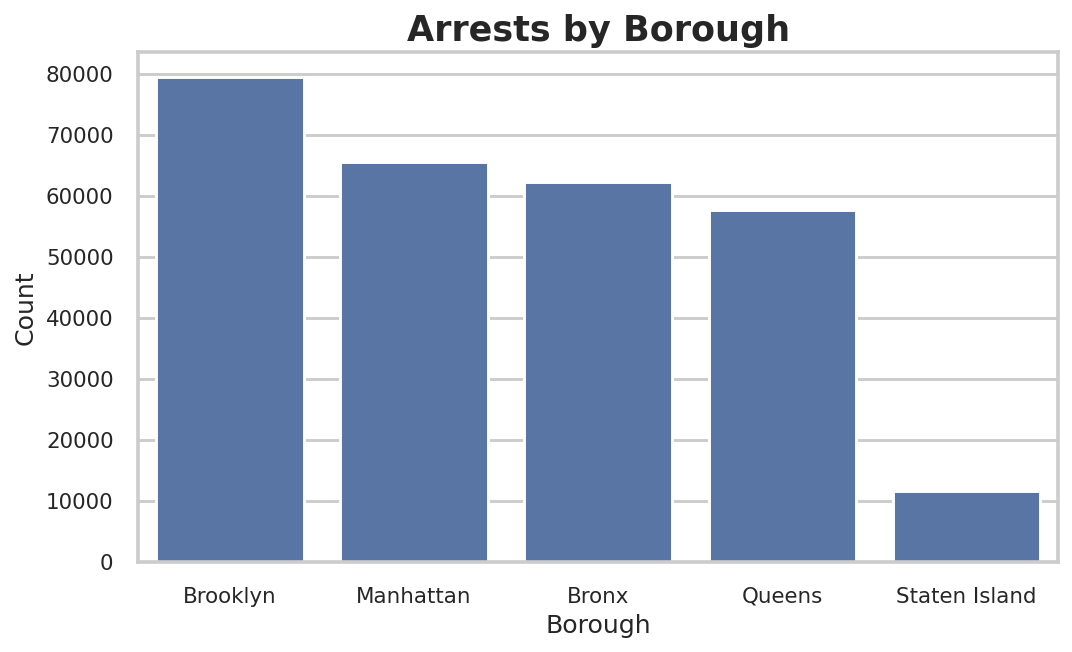

In [ ]:
# =====================================================
# Basic EDA 5: Arrest Distribution by Borough
# =====================================================

boro_counts = df_clean["ARREST_BORO"].value_counts()

plt.figure(figsize=(8,5))
sns.barplot(x=boro_counts.index, y=boro_counts.values)

plt.title("Arrests by Borough")
plt.xlabel("Borough")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

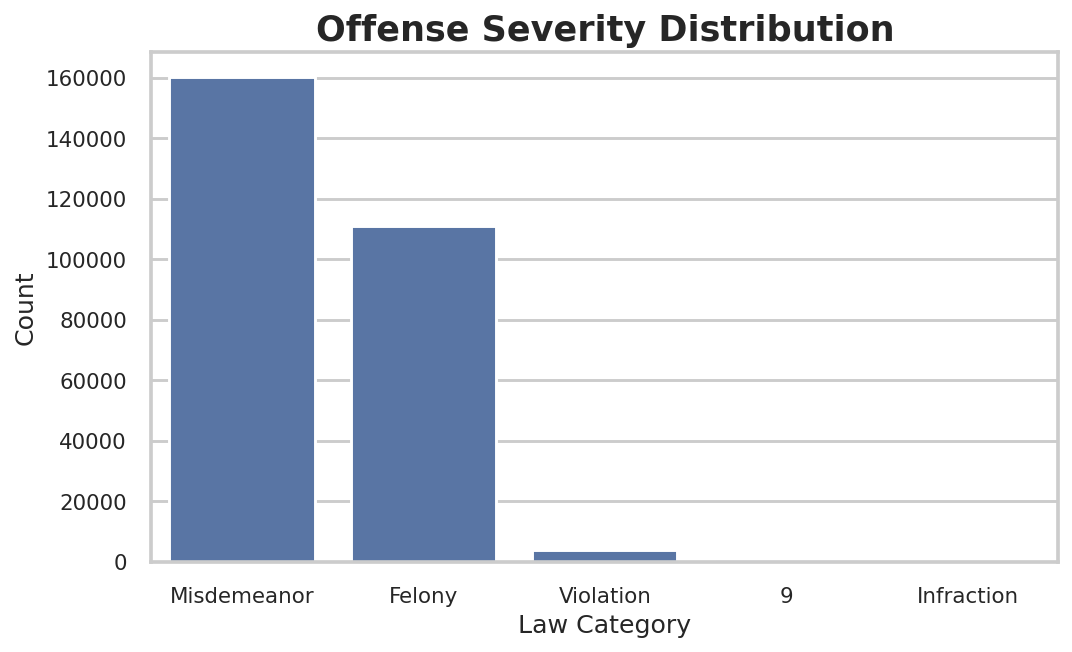

In [ ]:
# =====================================================
# Basic EDA 6: Offense Severity Distribution
# =====================================================

law_counts = df_clean["LAW_CAT_CD"].value_counts()

plt.figure(figsize=(8,5))
sns.barplot(x=law_counts.index, y=law_counts.values)

plt.title("Offense Severity Distribution")
plt.xlabel("Law Category")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

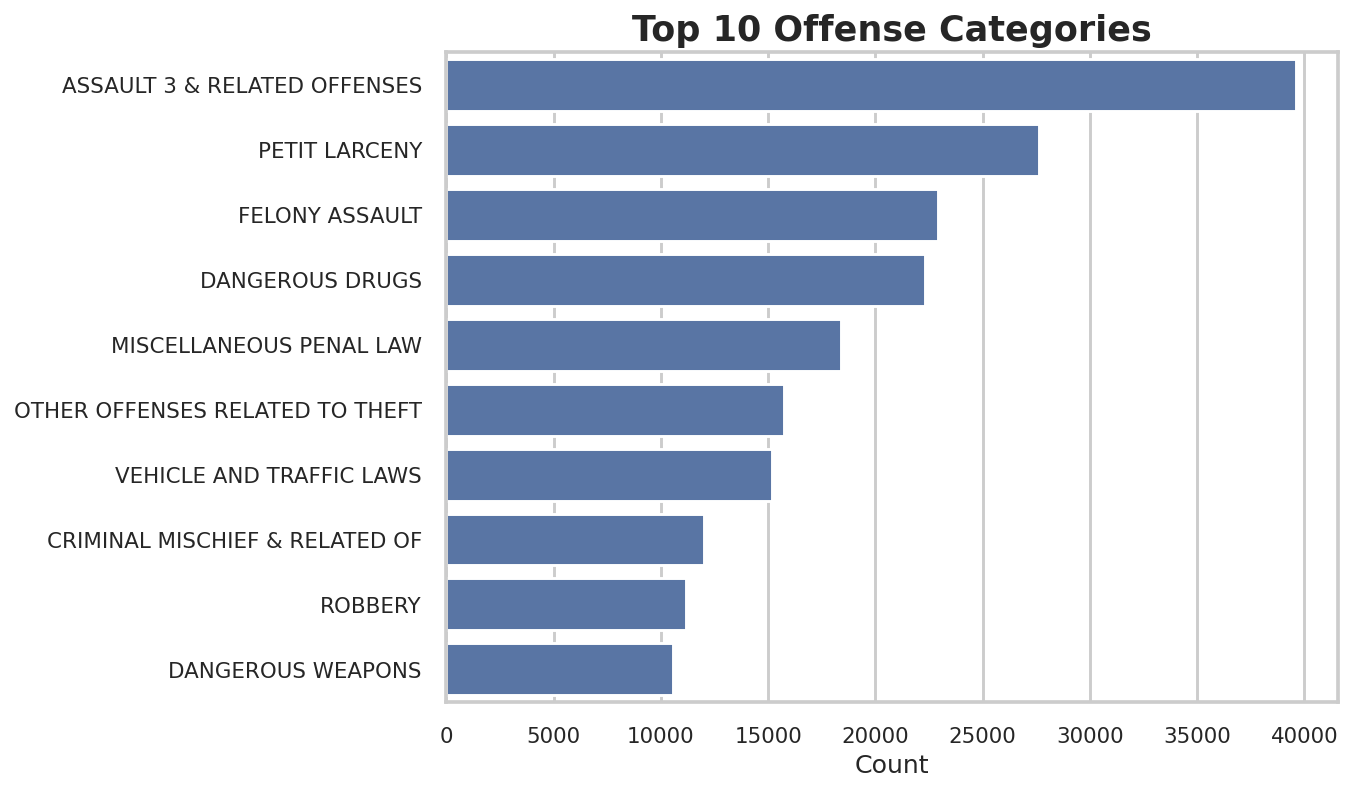

In [ ]:
# =====================================================
# Basic EDA 7: Top 10 Offense Categories
# =====================================================

top_offense = df_clean["OFNS_DESC"].value_counts().head(10)

plt.figure(figsize=(10,6))
sns.barplot(y=top_offense.index, x=top_offense.values)

plt.title("Top 10 Offense Categories")
plt.xlabel("Count")
plt.ylabel("")
plt.tight_layout()
plt.show()

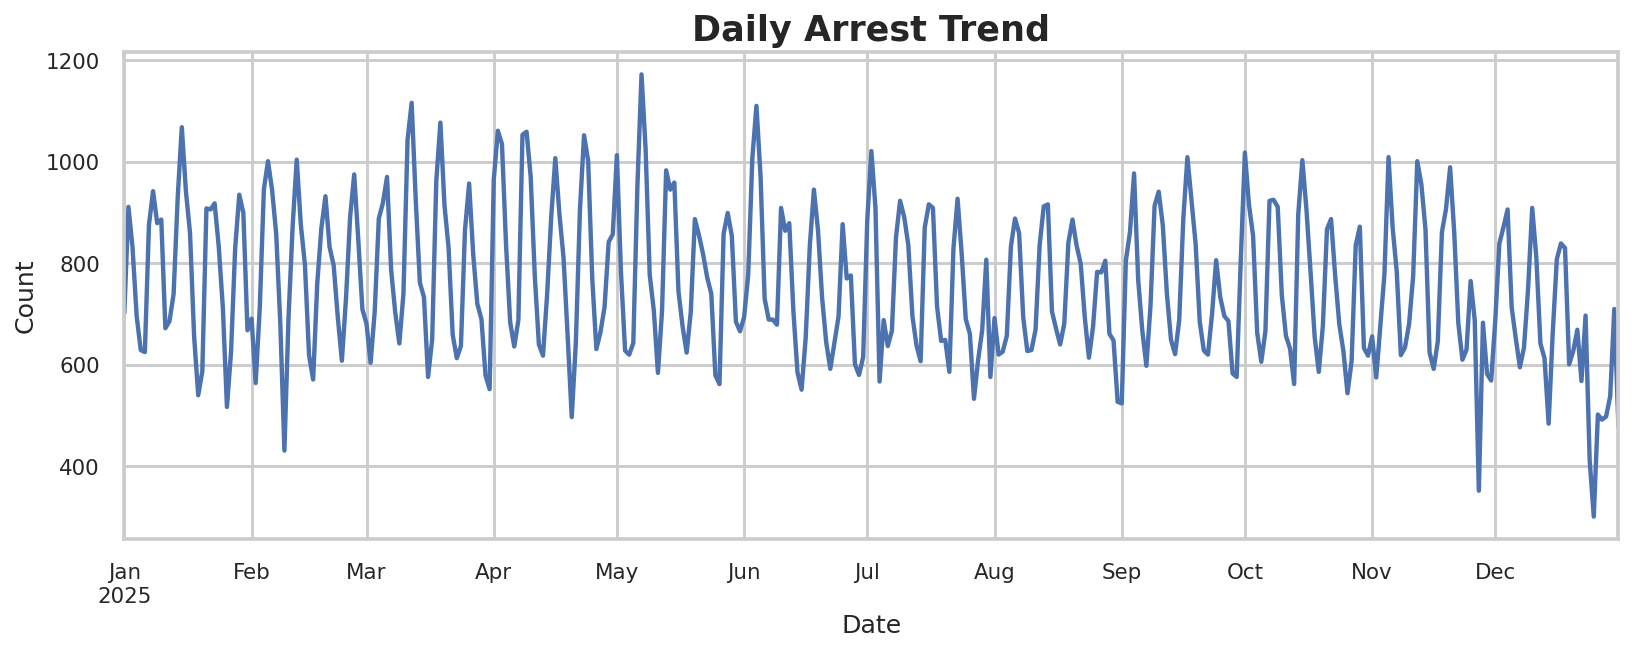

In [ ]:
# =====================================================
# Basic EDA 8: Arrest Trend Over Time
# =====================================================

daily_counts = df_clean.groupby("ARREST_DATE").size()

plt.figure(figsize=(12,5))
daily_counts.plot()

plt.title("Daily Arrest Trend")
plt.xlabel("Date")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

##**Part 2: Static Visualization & Publication-Quality Charts**
This section builds directly on the master_cleaned.csv exported in Part 1 and produces polished static charts for the final report, slides, and dashboard handoff.

In [ ]:
import os
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import altair as alt

###**2.1 Style settings**

In [ ]:
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (12, 7)
plt.rcParams["axes.titlesize"] = 18
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelsize"] = 13
plt.rcParams["xtick.labelsize"] = 11
plt.rcParams["ytick.labelsize"] = 11
plt.rcParams["legend.fontsize"] = 11
plt.rcParams["figure.dpi"] = 140
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["savefig.bbox"] = "tight"

# A consistent palette across Part 2
BORO_ORDER = ["Bronx", "Brooklyn", "Manhattan", "Queens", "Staten Island"]
BORO_PALETTE = {
    "Bronx": "#6C8EBF",
    "Brooklyn": "#D97B66",
    "Manhattan": "#7AA874",
    "Queens": "#C8A951",
    "Staten Island": "#8E7DBE"
}
SEVERITY_ORDER = ["Felony", "Misdemeanor", "Violation", "Infraction"]
SEVERITY_PALETTE = {
    "Felony": "#C44E52",
    "Misdemeanor": "#4C72B0",
    "Violation": "#55A868",
    "Infraction": "#8172B2"
}

WEEKDAY_ORDER = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

# Output folder
OUTPUT_DIR = "static_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Part 2 libraries imported successfully.")

Part 2 libraries imported successfully.


In [ ]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import altair as alt

# Load & Validate Data
df = pd.read_csv("master_cleaned.csv", parse_dates=["ARREST_DATE"])

df["ARREST_DATE"] = pd.to_datetime(df["ARREST_DATE"], errors="coerce")
df["ARREST_BORO"] = df["ARREST_BORO"].astype(str).str.strip()
df["LAW_CAT_CD"] = df["LAW_CAT_CD"].astype(str).str.strip()
df["AGE_GROUP"] = df["AGE_GROUP"].astype(str).str.strip()
df["PERP_SEX"] = df["PERP_SEX"].astype(str).str.strip()
df["PERP_RACE"] = df["PERP_RACE"].astype(str).str.strip()
df["OFNS_DESC"] = df["OFNS_DESC"].astype(str).str.strip()

# Month key for trend charts
df["year_month"] = df["ARREST_DATE"].dt.to_period("M").dt.to_timestamp()

# Keep only standardized boroughs for clean visuals
df = df[df["ARREST_BORO"].isin(BORO_ORDER)].copy()

# Some charts should exclude residual / malformed labels
df["LAW_CAT_CD"] = df["LAW_CAT_CD"].replace({"9": np.nan})
df["PERP_SEX"] = df["PERP_SEX"].replace({"(null)": np.nan, "nan": np.nan})
df["AGE_GROUP"] = df["AGE_GROUP"].replace({"(null)": np.nan, "nan": np.nan})
df["PERP_RACE"] = df["PERP_RACE"].replace({"(null)": np.nan, "nan": np.nan})

print("Dataset loaded successfully.")
print("Shape:", df.shape)
print("Date range:", df["ARREST_DATE"].min().date(), "to", df["ARREST_DATE"].max().date())

# =====================================================
# Helper Function: Consistent chart cleanup
# =====================================================
def finish_chart(ax, title, subtitle=None, xlabel=None, ylabel=None):
    ax.set_title(title, pad=16)
    if subtitle:
        ax.text(
            0, 1.0, subtitle,
            transform=ax.transAxes,
            fontsize=11,
            color="dimgray",
            ha="left"
        )
    if xlabel is not None:
        ax.set_xlabel(xlabel)
    if ylabel is not None:
        ax.set_ylabel(ylabel)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


Dataset loaded successfully.
Shape: (276541, 29)
Date range: 2025-01-01 to 2025-12-31


###2.2 Monthly Arrest Trend by Borough

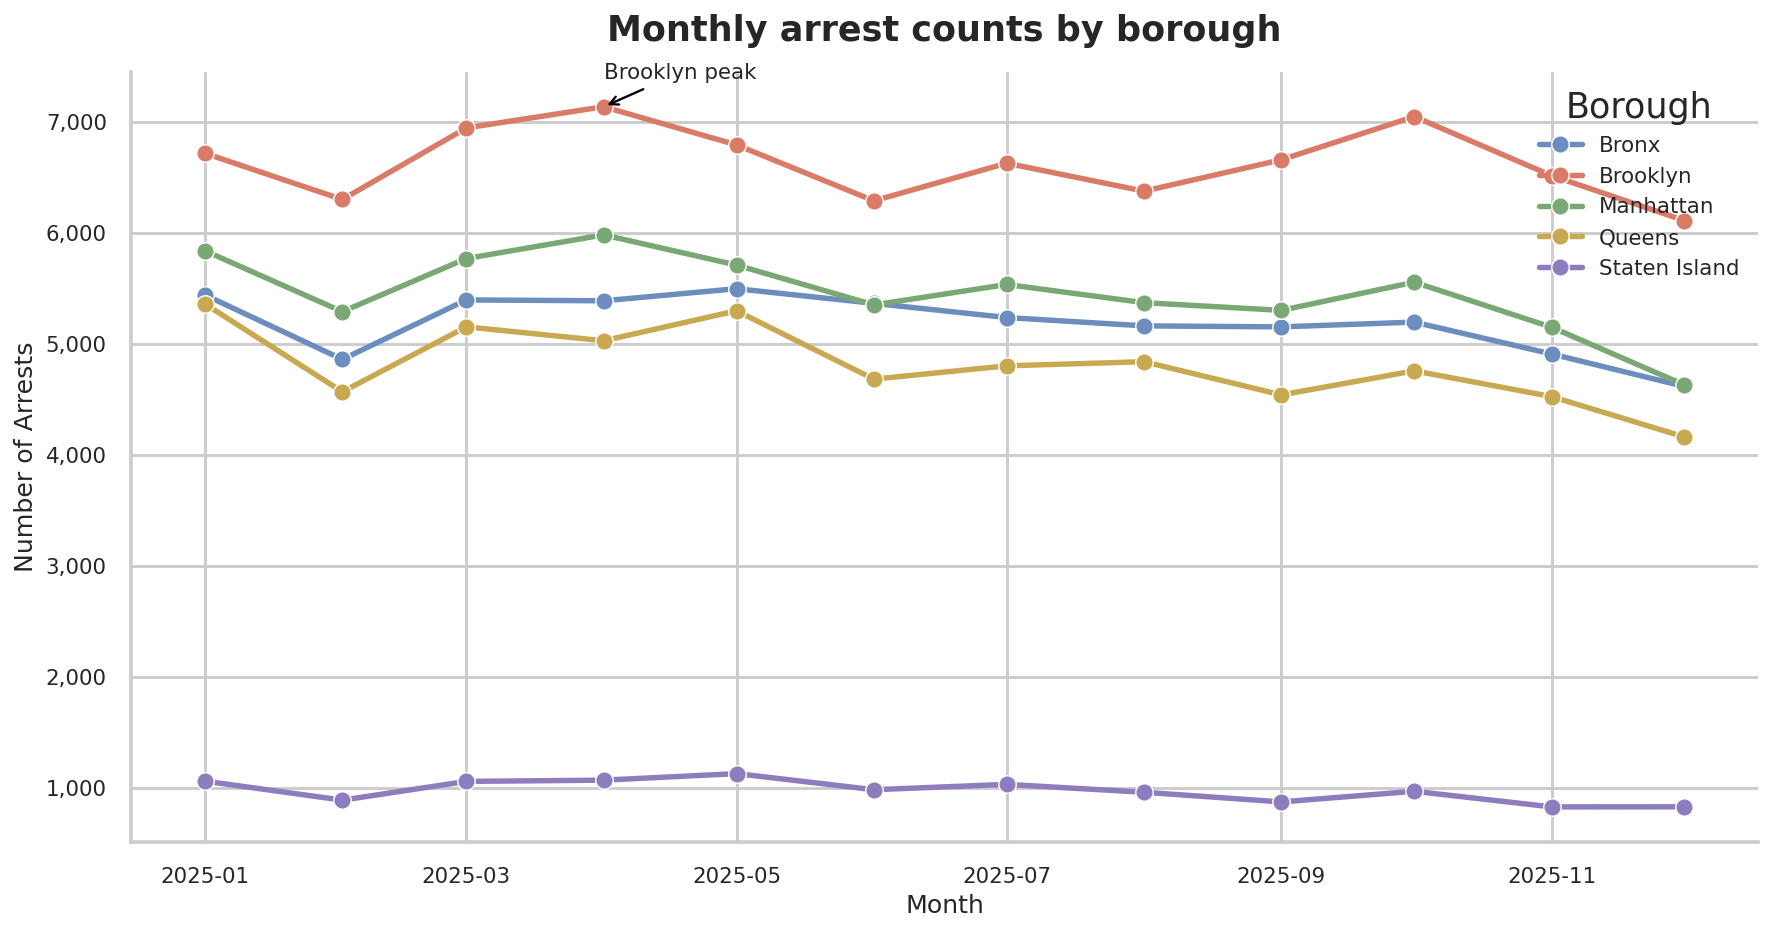

In [ ]:
monthly_boro = (
    df.groupby(["year_month", "ARREST_BORO"])
      .size()
      .reset_index(name="arrest_count")
)

fig, ax = plt.subplots(figsize=(13, 7))

sns.lineplot(
    data=monthly_boro,
    x="year_month",
    y="arrest_count",
    hue="ARREST_BORO",
    hue_order=BORO_ORDER,
    palette=BORO_PALETTE,
    linewidth=2.8,
    marker="o",
    ax=ax
)

# Annotate the borough with highest total arrests
boro_totals = (
    monthly_boro.groupby("ARREST_BORO")["arrest_count"]
    .sum()
    .sort_values(ascending=False)
)
top_boro = boro_totals.index[0]
top_boro_df = monthly_boro[monthly_boro["ARREST_BORO"] == top_boro]
peak_row = top_boro_df.loc[top_boro_df["arrest_count"].idxmax()]

ax.annotate(
    f"{top_boro} peak",
    xy=(peak_row["year_month"], peak_row["arrest_count"]),
    xytext=(peak_row["year_month"], peak_row["arrest_count"] + 250),
    arrowprops=dict(arrowstyle="->", lw=1.2, color="black"),
    fontsize=11
)

finish_chart(
    ax,
    title="Monthly arrest counts by borough",
    xlabel="Month",
    ylabel="Number of Arrests"
)

ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
plt.legend(title="Borough", frameon=False)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/02_monthly_trend_by_borough.png")
plt.show()


**Insight: Arrest volume remains consistently highest in Brooklyn and Manhattan throughout the year, suggesting that enforcement activity is more concentrated in these boroughs relative to Queens and Staten Island.**

###2.3 Top Offense Categories

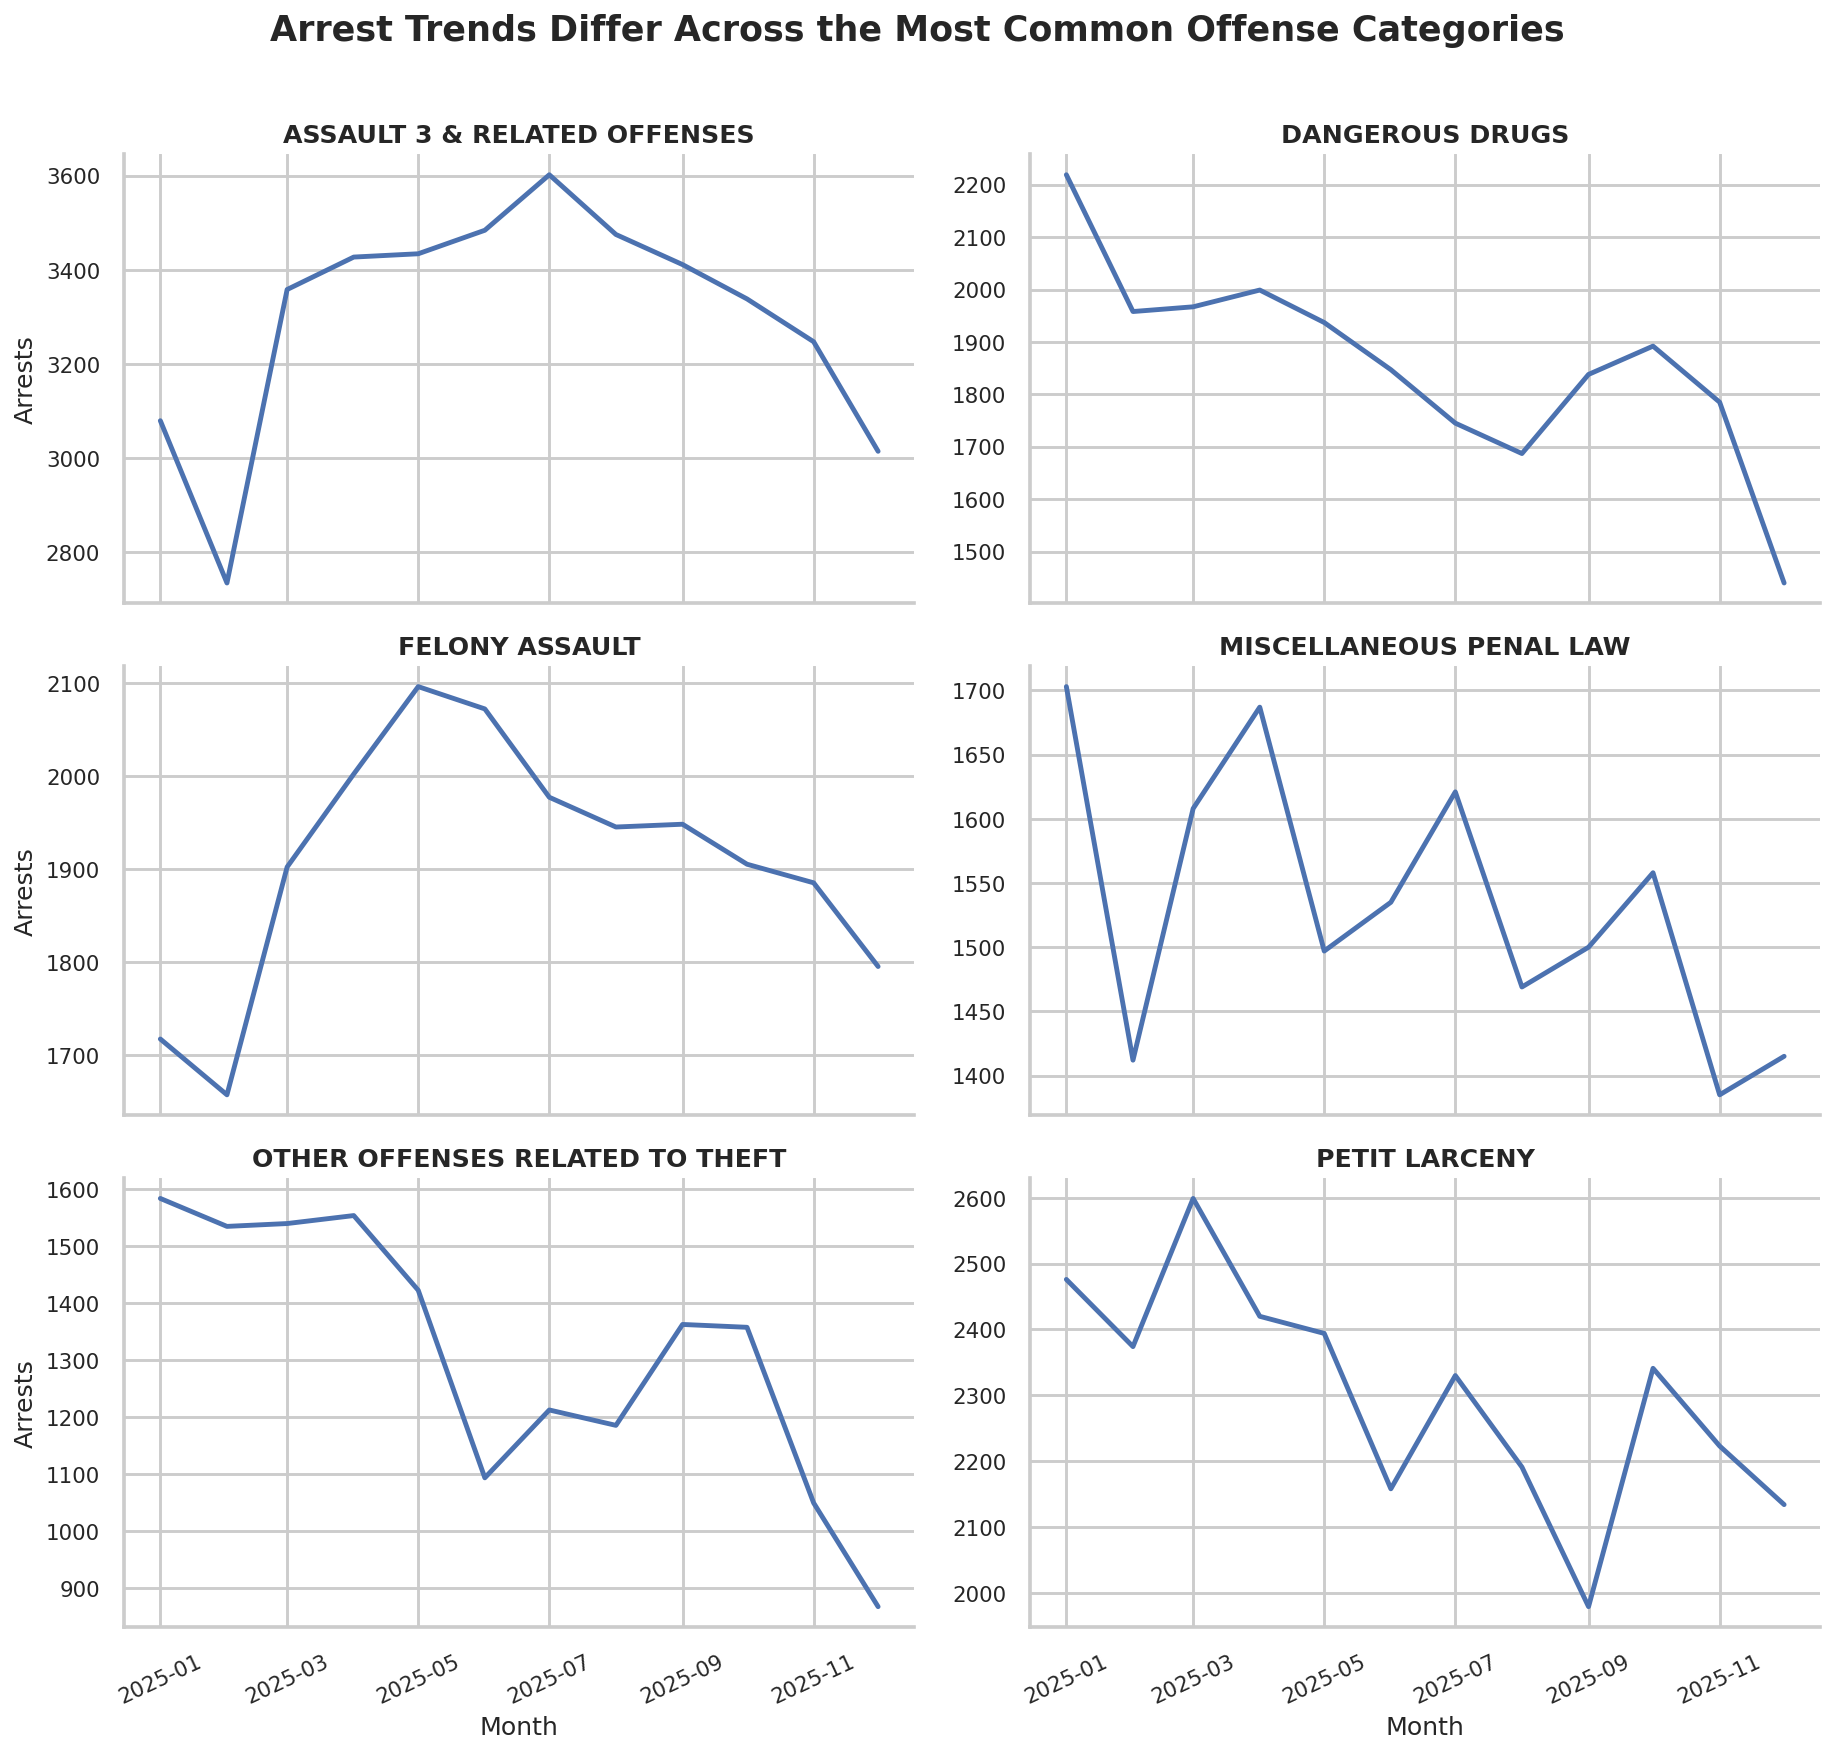

In [ ]:
# Monthly Arrest Trend for Top Offense Categories
top_offenses = (
    df["OFNS_DESC"]
    .value_counts()
    .head(6)
    .index
    .tolist()
)

offense_monthly = (
    df[df["OFNS_DESC"].isin(top_offenses)]
    .groupby(["year_month", "OFNS_DESC"])
    .size()
    .reset_index(name="arrest_count")
)

g = sns.FacetGrid(
    offense_monthly,
    col="OFNS_DESC",
    col_wrap=2,
    sharey=False,
    height=4.2,
    aspect=1.6
)
g.map_dataframe(
    sns.lineplot,
    x="year_month",
    y="arrest_count",
    linewidth=2.5,
    color="#4C72B0"
)
g.set_titles("{col_name}")
g.set_axis_labels("Month", "Arrests")

for ax in g.axes.flatten():
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(axis="x", rotation=25)

g.fig.subplots_adjust(top=0.90)
g.fig.suptitle(
    "Arrest Trends Differ Across the Most Common Offense Categories",
    fontsize=18,
    fontweight="bold"
)
plt.savefig(f"{OUTPUT_DIR}/03_monthly_trend_top_offenses.png")
plt.show()


**Insight: The most common offense categories exhibit distinct temporal patterns rather than moving in sync, suggesting that different types of offenses may be influenced by different underlying behavioral or enforcement dynamics.**

###2.4 Weekday × Borough Heatmap

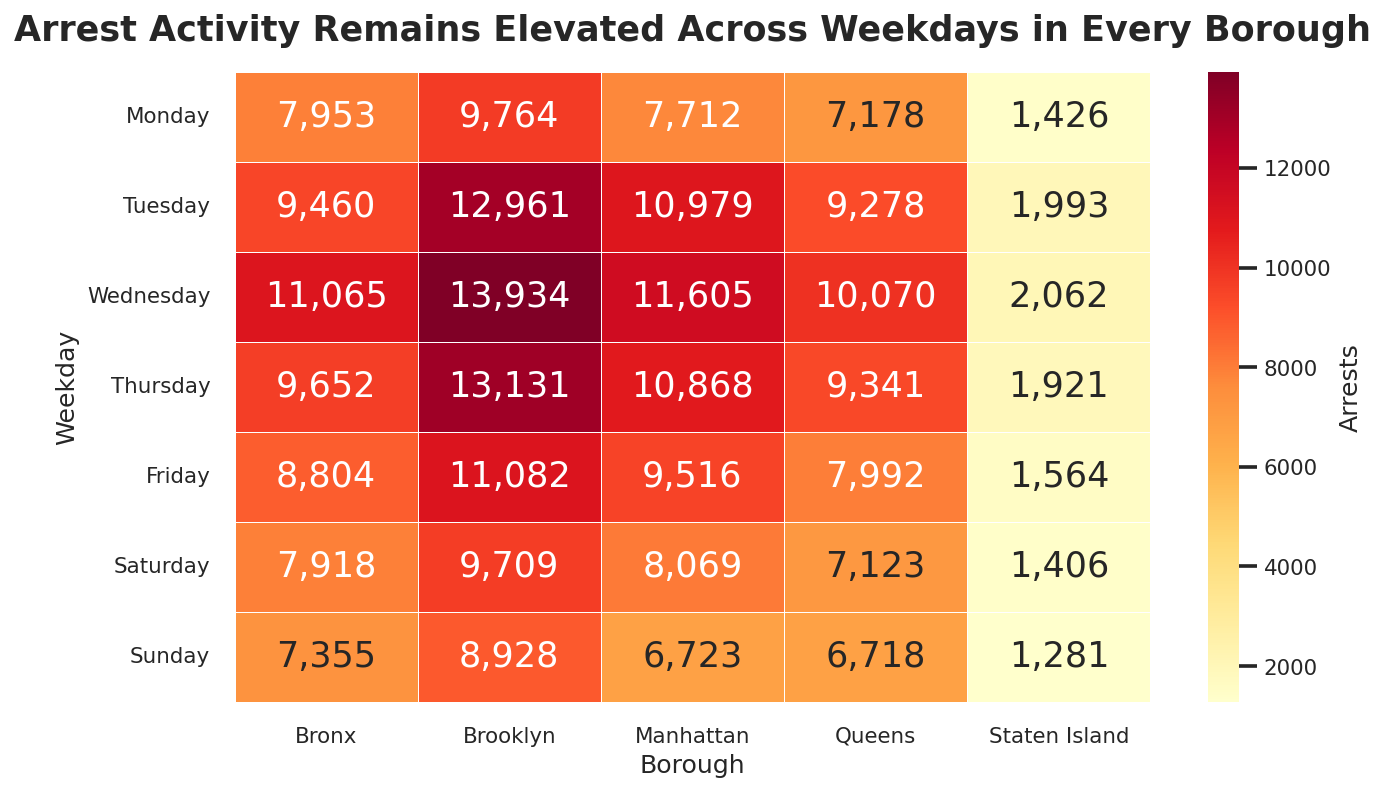

In [ ]:
# 2.4 Weekday × Borough Heatmap
weekday_boro = (
    df.groupby(["weekday", "ARREST_BORO"])
      .size()
      .reset_index(name="arrest_count")
)

weekday_boro["weekday"] = pd.Categorical(
    weekday_boro["weekday"],
    categories=WEEKDAY_ORDER,
    ordered=True
)
weekday_boro["ARREST_BORO"] = pd.Categorical(
    weekday_boro["ARREST_BORO"],
    categories=BORO_ORDER,
    ordered=True
)

heatmap_df = weekday_boro.pivot(
    index="weekday",
    columns="ARREST_BORO",
    values="arrest_count"
).loc[WEEKDAY_ORDER, BORO_ORDER]

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(
    heatmap_df,
    annot=True,
    fmt=",.0f",
    cmap="YlOrRd",
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Arrests"},
    ax=ax
)

finish_chart(
    ax,
    title="Arrest Activity Remains Elevated Across Weekdays in Every Borough",
    xlabel="Borough",
    ylabel="Weekday"
)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/04_weekday_borough_heatmap.png")
plt.show()


**Insight: Arrest activity remains consistently distributed across weekdays in all boroughs, indicating that enforcement patterns are not driven solely by weekend spikes but reflect more continuous policing activity throughout the week.**

###2.5 Offense Severity Composition by Borough

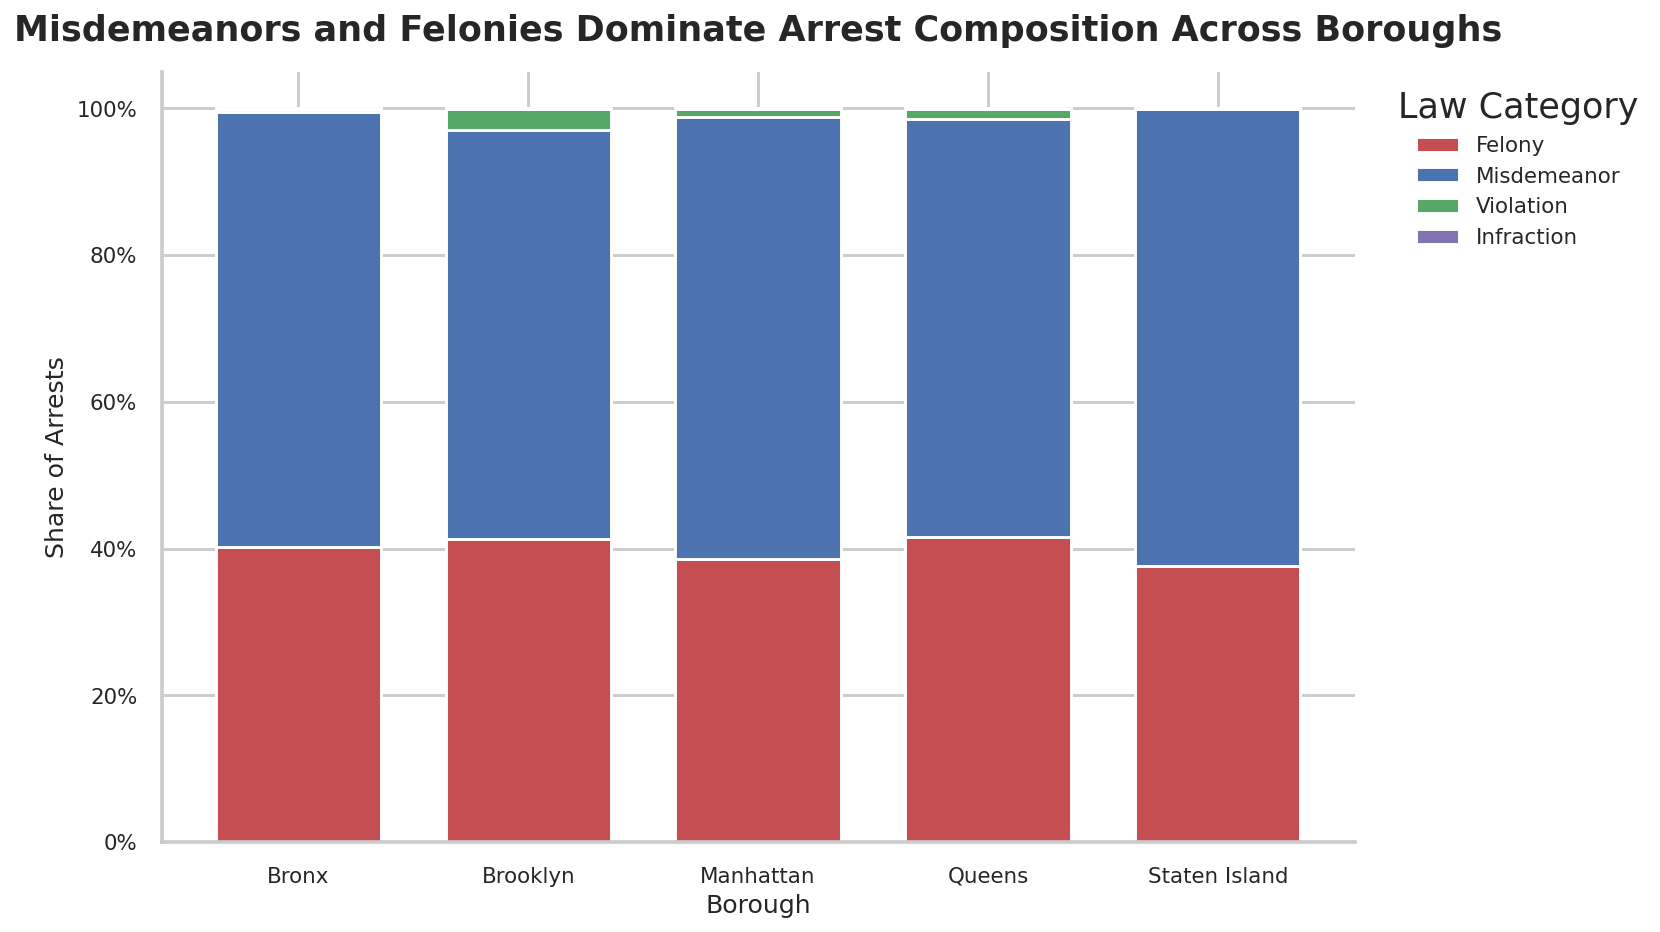

In [ ]:
# Offense Severity Composition by Borough (100% Stacked Bar)
severity_boro = (
    df[df["LAW_CAT_CD"].isin(SEVERITY_ORDER)]
    .groupby(["ARREST_BORO", "LAW_CAT_CD"])
    .size()
    .reset_index(name="count")
)

severity_pivot = severity_boro.pivot(
    index="ARREST_BORO",
    columns="LAW_CAT_CD",
    values="count"
).fillna(0)

severity_pivot = severity_pivot.reindex(BORO_ORDER)
severity_pivot = severity_pivot.reindex(columns=SEVERITY_ORDER, fill_value=0)

severity_pct = severity_pivot.div(severity_pivot.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(12, 7))

bottom = np.zeros(len(severity_pct))
x = np.arange(len(severity_pct.index))

for sev in SEVERITY_ORDER:
    values = severity_pct[sev].values
    ax.bar(
        x,
        values,
        bottom=bottom,
        color=SEVERITY_PALETTE[sev],
        label=sev,
        width=0.72
    )
    bottom += values

ax.set_xticks(x)
ax.set_xticklabels(severity_pct.index)
ax.yaxis.set_major_formatter(mticker.PercentFormatter())

finish_chart(
    ax,
    title="Misdemeanors and Felonies Dominate Arrest Composition Across Boroughs",
    xlabel="Borough",
    ylabel="Share of Arrests"
)

plt.legend(title="Law Category", frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/05_severity_composition_by_borough.png")
plt.show()

**Insight: Across all boroughs, misdemeanors and felonies account for the majority of arrests, while violations and infractions represent a much smaller share, indicating that enforcement is primarily concentrated on more serious offenses.**

###2.6 Demographic Charts

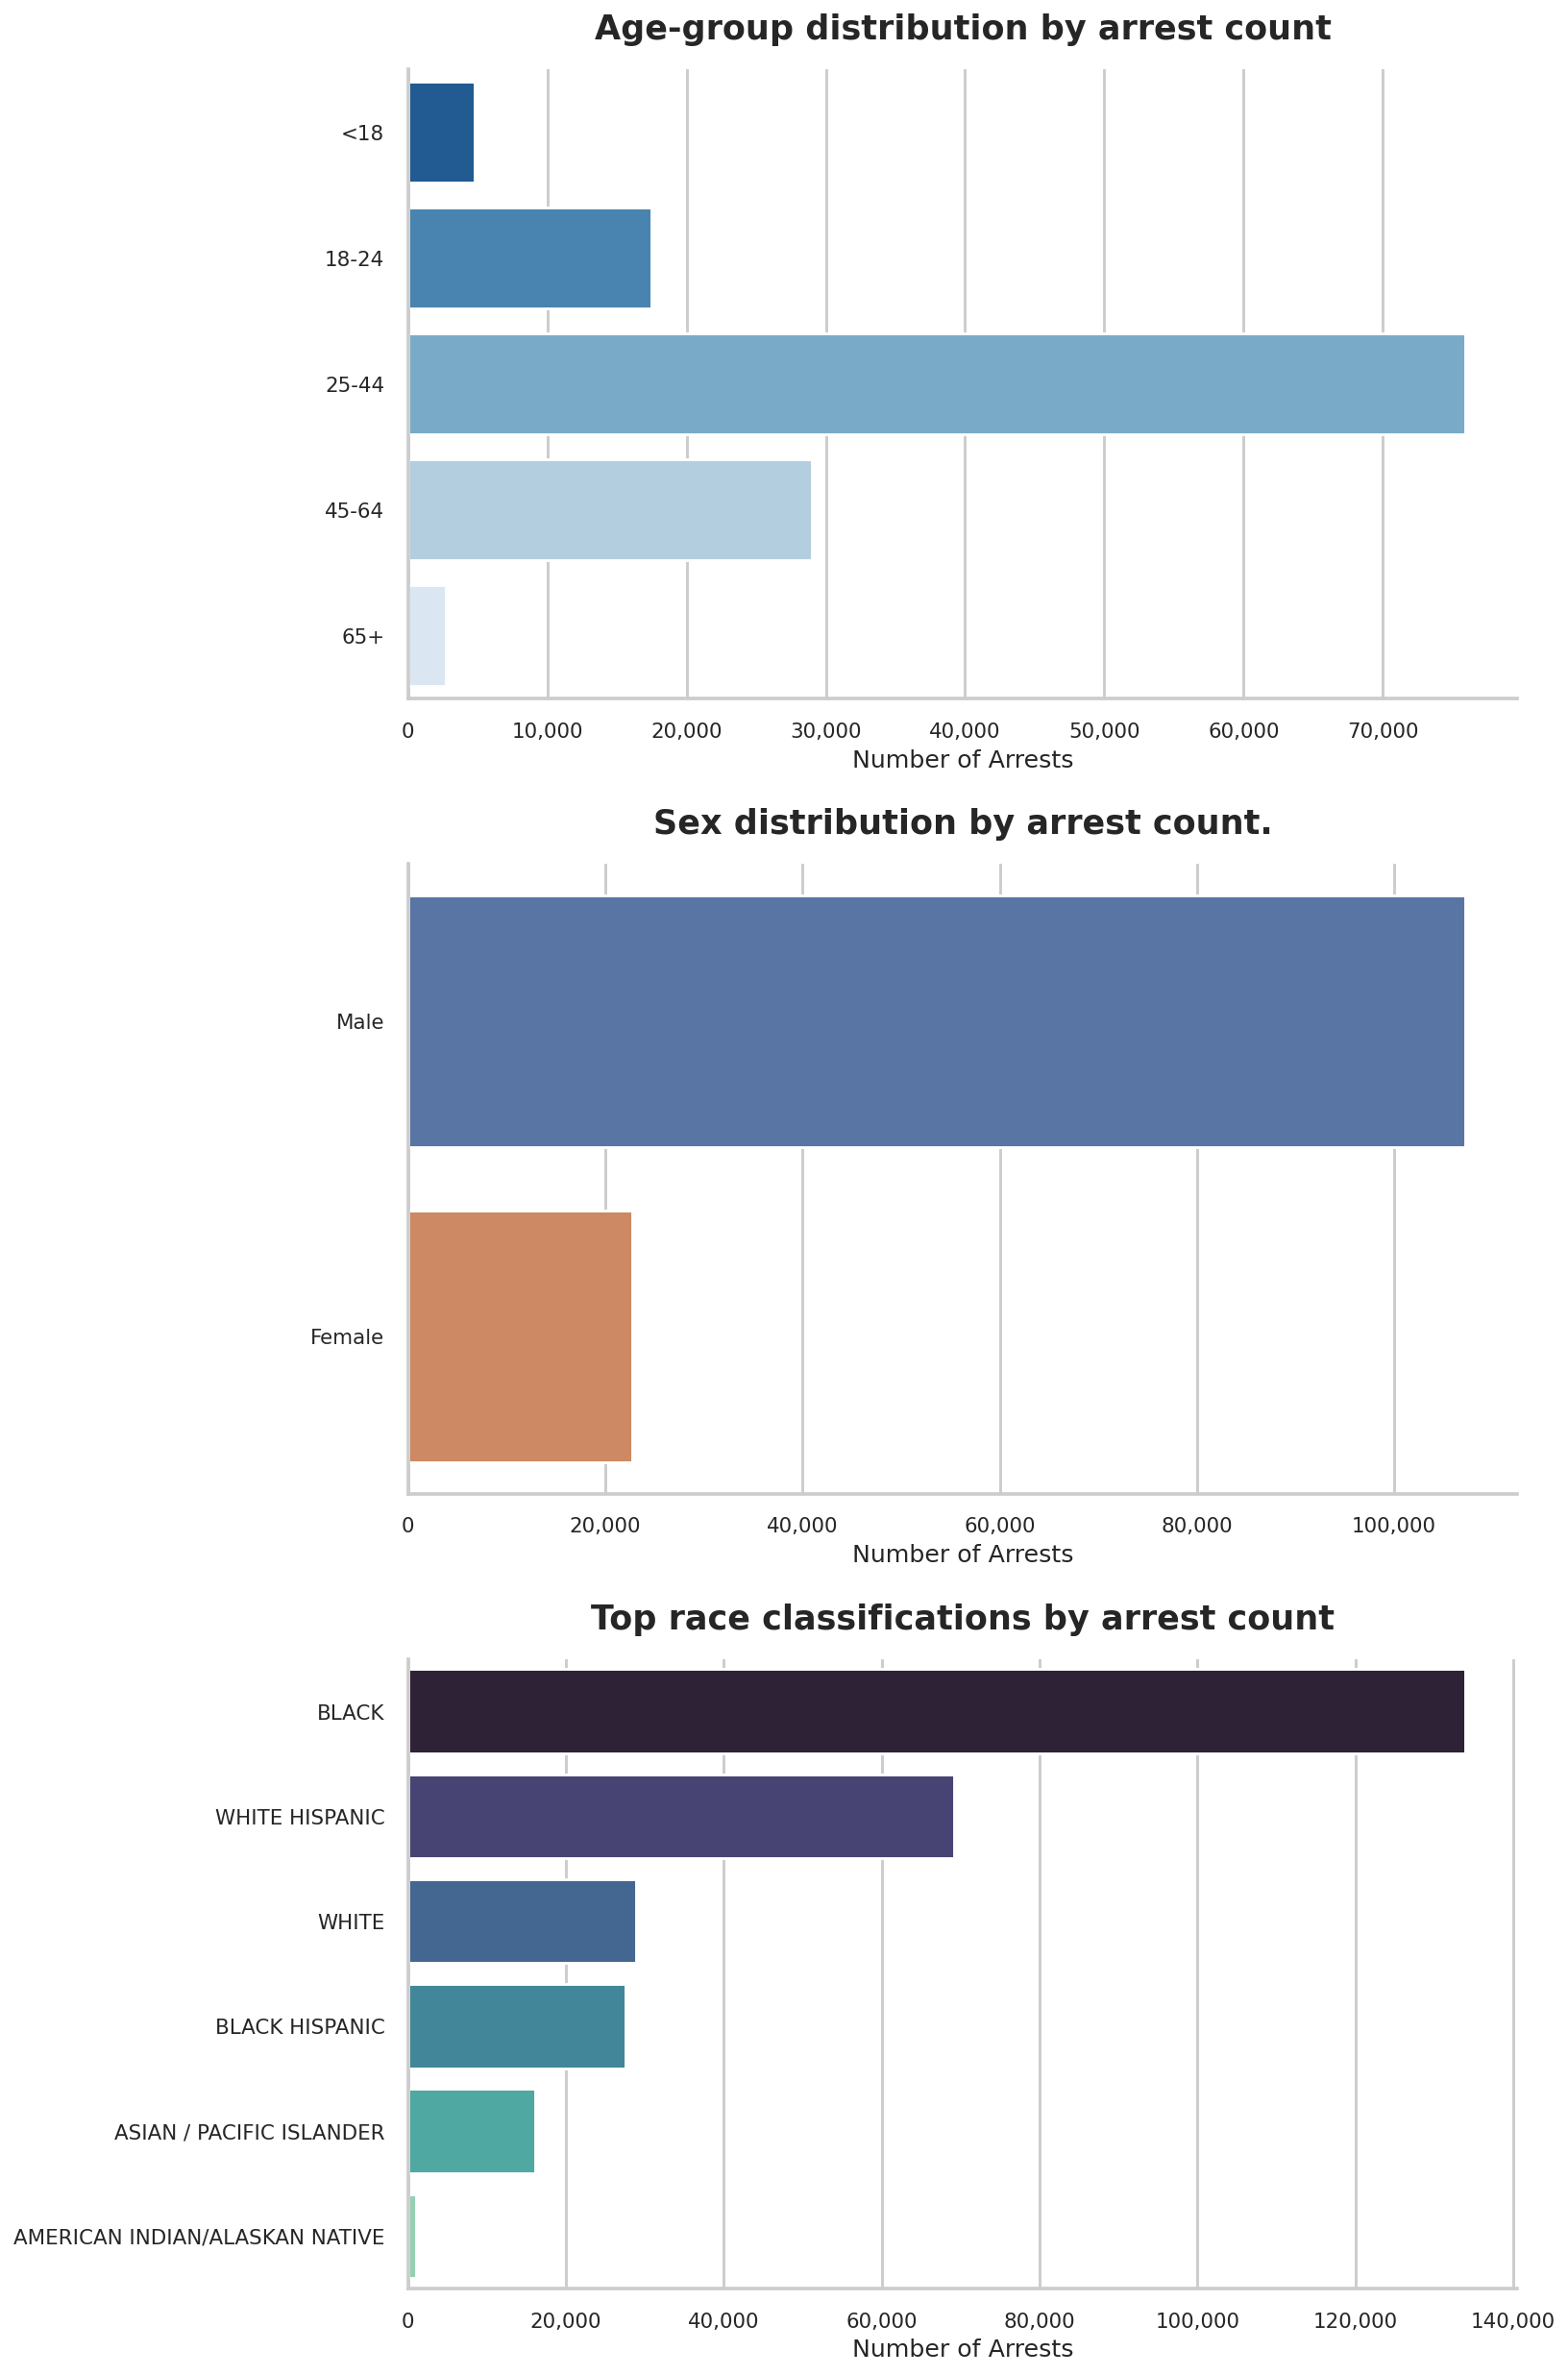

In [ ]:
# Demographic Charts
fig, axes = plt.subplots(3, 1, figsize=(12, 18))

# 2.6.1 Age Group
age_counts = (
    df[df["AGE_GROUP"].notna()]
    .groupby("AGE_GROUP")
    .size()
    .reindex(["<18", "18-24", "25-44", "45-64", "65+"])
    .dropna()
)

sns.barplot(
    x=age_counts.values,
    y=age_counts.index,
    palette=sns.color_palette("Blues_r", len(age_counts)),
    ax=axes[0]
)
finish_chart(
    axes[0],
    title="Age-group distribution by arrest count",
    xlabel="Number of Arrests",
    ylabel=""
)
axes[0].xaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))

# 2.6.2 Sex
sex_counts = (
    df[df["PERP_SEX"].notna()]
    .groupby("PERP_SEX")
    .size()
    .sort_values(ascending=False)
)

sns.barplot(
    x=sex_counts.values,
    y=sex_counts.index,
    palette=["#4C72B0", "#DD8452"][:len(sex_counts)],
    ax=axes[1]
)
finish_chart(
    axes[1],
    title="Sex distribution by arrest count.",
    xlabel="Number of Arrests",
    ylabel=""
)
axes[1].xaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))

# 2.6.3 Race
race_counts = (
    df[df["PERP_RACE"].notna()]
    .groupby("PERP_RACE")
    .size()
    .sort_values(ascending=False)
    .head(8)
)

sns.barplot(
    x=race_counts.values,
    y=race_counts.index,
    palette=sns.color_palette("mako", len(race_counts)),
    ax=axes[2]
)
finish_chart(
    axes[2],
    title="Top race classifications by arrest count",
    xlabel="Number of Arrests",
    ylabel=""
)
axes[2].xaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/06_demographic_charts.png")
plt.show()


**Insight: Arrests are heavily concentrated among individuals aged 25–44, with males accounting for the majority of cases, reflecting a strong demographic skew in enforcement patterns.**

##**Part 3: Spatial Analysis & Interactive Dashboard**

Builds directly on `master_cleaned.csv` (256,965 rows × 28 columns, exported from Section 1 Step 17).  
Borough labels (`Queens`, `Brooklyn`, …) and severity labels (`Felony`, `Misdemeanor`, …) are already standardized.  
Date range: **2025-01-01 → 2025-12-30**.

| # | Deliverable | Tool |
|---|---|---|
| 3.1 | Load & validate spatial data | pandas |
| 3.2 | Choropleth map — arrest density by precinct | GeoPandas + Plotly |
| 3.3 | Folium marker cluster map | Folium |
| 3.4 | PyDeck hexbin hotspot map | PyDeck |
| 3.5 | Side-by-side borough comparison (static) | Altair + Matplotlib |
| 3.6 | Streamlit interactive dashboard (`app.py`) | Streamlit |

---
### 3.1 Load Data & Spatial Setup

In [ ]:
# =====================================================
# Part 3 — Additional Library Imports
# (pandas, numpy, matplotlib, seaborn, altair already
#  imported in Section 1 — re-import here for safety)
# =====================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import altair as alt
import warnings
warnings.filterwarnings("ignore")

# Geospatial
import geopandas as gpd
import folium
from folium.plugins import MarkerCluster
import pydeck as pdk

# Interactive
import plotly.express as px
from IPython.display import IFrame, display

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
pd.set_option("display.max_columns", None)

print("Part 3 libraries imported successfully.")

ModuleNotFoundError: No module named 'pydeck'

In [ ]:
# =====================================================
# 3.1.1 Load master_cleaned.csv
# =====================================================
# Output of Section 1, Step 17.
# 256,965 rows x 28 columns; date range 2025-01 to 2025-12.
#
# Key columns used in Part 3:
#   ARREST_DATE, ARREST_BORO, ARREST_PRECINCT, OFNS_DESC,
#   LAW_CAT_CD, PERP_RACE, Latitude, Longitude
#   + derived: year, month, month_name, weekday (from cleaning)

df = pd.read_csv("master_cleaned.csv", parse_dates=["ARREST_DATE"])

df["ARREST_DATE"] = pd.to_datetime(df["ARREST_DATE"], errors="coerce")
df["Latitude"]    = pd.to_numeric(df["Latitude"],  errors="coerce")
df["Longitude"]   = pd.to_numeric(df["Longitude"], errors="coerce")

print("Dataset loaded. Shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head(3)

In [ ]:
# =====================================================
# 3.1.2 Data prep for Part 3
# =====================================================

# year_month column for trend charts
df["year_month"] = df["ARREST_DATE"].dt.to_period("M").dt.to_timestamp()

# Reference lists
# Note: LAW_CAT_CD contains a residual '9' value (unclassified);
# we filter to KNOWN_SEVERITY in charts that need clean labels.
KNOWN_BOROS    = ["Bronx", "Brooklyn", "Manhattan", "Queens", "Staten Island"]
KNOWN_SEVERITY = ["Felony", "Misdemeanor", "Violation", "Infraction"]

print("LAW_CAT_CD value counts:")
print(df["LAW_CAT_CD"].value_counts())
print()

# Geo-valid subset (NYC bounding box) for point / hexbin maps
df_geo = df[
    df["Latitude"].between(40.45, 40.95) &
    df["Longitude"].between(-74.30, -73.65)
].copy()

print(f"Total rows:               {len(df):,}")
print(f"Rows with valid coords:   {len(df_geo):,}")
print(f"Date range: {df['ARREST_DATE'].min().date()} to {df['ARREST_DATE'].max().date()}")

---
### 3.2 Choropleth Map — Arrest Density by Precinct

Fetch the NYPD precinct boundary GeoJSON from NYC Open Data, join with per-precinct arrest counts from `master_cleaned.csv`, and render an interactive Plotly choropleth.

In [ ]:
# =====================================================
# 3.2.1 Load NYPD Precinct Boundaries (GeoJSON)
# =====================================================
# The old Socrata export URL (?method=export&type=GeoJSON)
# returns HTTP 400. Use the SODA API endpoint instead,
# with two GitHub/ArcGIS fallbacks.

import requests
import io

PRECINCT_URLS = [
    # 1. Socrata SODA API — correct endpoint for NYC Open Data
    "https://data.cityofnewyork.us/resource/kmep-waad.geojson?$limit=200",
    # 2. GitHub mirror (geoplot project)
    "https://raw.githubusercontent.com/ResidentMario/geoplot-data/master/nyc-police-precincts.geojson",
    # 3. ArcGIS Hub FeatureServer
    "https://services5.arcgis.com/GfwWNkhOj9bNBqoJ/arcgis/rest/services/nypp/FeatureServer/0/query?where=1%3D1&outFields=*&outSR=4326&f=geojson",
]

precincts_gdf = None
for url in PRECINCT_URLS:
    try:
        resp = requests.get(url, timeout=20)
        resp.raise_for_status()
        precincts_gdf = gpd.read_file(io.BytesIO(resp.content))
        print(f"Loaded from:\n  {url}")
        break
    except Exception as e:
        print(f"Failed: {e}\n  URL: {url}")

if precincts_gdf is None:
    raise RuntimeError(
        "All URLs failed. Download manually:\n"
        "  https://data.cityofnewyork.us/resource/kmep-waad.geojson\n"
        "Save as nyc_precincts.geojson and run:\n"
        "  precincts_gdf = gpd.read_file('nyc_precincts.geojson')"
    )

precincts_gdf = precincts_gdf.to_crs(epsg=4326)
print("Columns:", precincts_gdf.columns.tolist())
print("CRS:", precincts_gdf.crs)
precincts_gdf.head(3)

In [ ]:
# =====================================================
# 3.2.2 Align Precinct IDs & Merge Arrest Counts
# =====================================================
# ARREST_PRECINCT in master_cleaned.csv is float64.
# NYC Open Data GeoJSON uses 'precinct' (string).
# Normalize both to numeric for the merge.

precinct_col = [
    c for c in precincts_gdf.columns
    if c.lower() in ("precinct", "pct", "prct")
][0]
print(f"Precinct column in GeoJSON: '{precinct_col}'")

precincts_gdf["precinct_id"] = pd.to_numeric(
    precincts_gdf[precinct_col], errors="coerce"
)

# Aggregate arrests per precinct
precinct_counts = (
    df.groupby("ARREST_PRECINCT")
    .size()
    .reset_index(name="arrest_count")
    .rename(columns={"ARREST_PRECINCT": "precinct_id"})
)
precinct_counts["precinct_id"] = pd.to_numeric(
    precinct_counts["precinct_id"], errors="coerce"
)

precincts_merged = precincts_gdf.merge(
    precinct_counts, on="precinct_id", how="left"
)
precincts_merged["arrest_count"] = (
    precincts_merged["arrest_count"].fillna(0).astype(int)
)

print(f"Merged shape: {precincts_merged.shape}")
print(
    f"Arrest count range: "
    f"{precincts_merged['arrest_count'].min()} to "
    f"{precincts_merged['arrest_count'].max()}"
)
precincts_merged[["precinct_id", "arrest_count"]] \
    .sort_values("arrest_count", ascending=False).head(10)

In [ ]:
# =====================================================
# 3.2.3 Interactive Choropleth with Plotly
# =====================================================

fig_choropleth = px.choropleth_mapbox(
    precincts_merged,
    geojson=precincts_merged.__geo_interface__,
    locations=precincts_merged.index,
    color="arrest_count",
    color_continuous_scale="YlOrRd",
    mapbox_style="carto-positron",
    zoom=9.5,
    center={"lat": 40.71, "lon": -73.98},
    opacity=0.65,
    hover_data={"precinct_id": True, "arrest_count": True},
    labels={"arrest_count": "Arrests", "precinct_id": "Precinct"},
    title="NYC Arrest Density by Police Precinct (2025 YTD)",
)
fig_choropleth.update_layout(
    margin={"r": 0, "t": 40, "l": 0, "b": 0},
    coloraxis_colorbar=dict(title="Arrests"),
    title_font_size=15,
)
fig_choropleth.show()

fig_choropleth.write_html("fig_choropleth_precinct.html")
print("Saved to fig_choropleth_precinct.html")

##**Part 4: Advanced Analytics — NLP & Network Visualization**

**Street-Level Stories: An Interactive Visual Analysis of NYC Arrest Patterns**

This section covers the high-level analytical components of the project:

- **NLP / Text Analysis** — BERTopic topic modeling on offense descriptions, keyword extraction, and interactive topic visualizations
- **Network Analysis** — Precinct similarity network and offense co-occurrence graph using NetworkX + PyVis

All analysis builds directly on the `master_cleaned.csv` produced in Part 1 (Data Cleaning).

### Deliverables

| # | Visualization | Tool |
|---|---------------|------|
| 4.1 | BERTopic topic modeling on `PD_DESC` + `OFNS_DESC` | BERTopic, sentence-transformers |
| 4.2 | Interactive topic bubble chart | Plotly |
| 4.3 | Topic mix heatmap across boroughs | Seaborn / Matplotlib |
| 4.4 | Keyword extraction per topic cluster | spaCy / CountVectorizer |
| 4.5 | Precinct similarity network (cosine similarity) | NetworkX + PyVis |
| 4.6 | Offense co-occurrence network | NetworkX + PyVis |

---
## 4.0 Environment Setup

In [ ]:
# =====================================================
# 4.0.1 Install Required Libraries
# =====================================================
# Run this cell once to install any missing packages.

!pip install bertopic sentence-transformers spacy networkx pyvis plotly umap-learn hdbscan --quiet
!python -m spacy download en_core_web_sm --quiet

print("Installation complete.")

In [ ]:
# =====================================================
# 4.0.2 Import Libraries
# =====================================================

import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# NLP
import spacy
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from umap import UMAP
from hdbscan import HDBSCAN

# Network
import networkx as nx
from pyvis.network import Network
from IPython.display import display, HTML

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

# Load spaCy model
nlp = spacy.load("en_core_web_sm")

print("All libraries imported successfully.")

In [ ]:
# =====================================================
# 4.0.3 Load Master Cleaned Dataset
# =====================================================
# Prefer parquet for speed; fall back to CSV.

if os.path.exists("master.parquet"):
    df = pd.read_parquet("master.parquet")
    print("Loaded from master.parquet")
else:
    df = pd.read_csv("master_cleaned.csv", parse_dates=["ARREST_DATE"])
    print("Loaded from master_cleaned.csv")

df["ARREST_DATE"] = pd.to_datetime(df["ARREST_DATE"], errors="coerce")

print(f"Dataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
df.head(3)

---
## Part A: NLP — Offense Text Analysis

The `PD_DESC` and `OFNS_DESC` columns contain hundreds of unique offense labels. We concatenate both fields to create an enriched text representation and apply **BERTopic** to cluster them into interpretable themes. This reveals latent groupings beyond the raw administrative labels.

### 4.1 Text Preparation

In [ ]:
# =====================================================
# 4.1.1 Prepare Offense Text Corpus
# =====================================================
# Strategy:
#   1. Concatenate PD_DESC + OFNS_DESC for richer input.
#   2. Deduplicate: model at the unique-description level
#      (then map topics back to full dataset).
#   3. Clean strings — lowercase, strip extra spaces.

df_text = df[["PD_DESC", "OFNS_DESC", "ARREST_BORO", "ARREST_PRECINCT"]].copy()

# Fill nulls with empty string before concat
df_text["PD_DESC"]   = df_text["PD_DESC"].fillna("").str.strip().str.lower()
df_text["OFNS_DESC"] = df_text["OFNS_DESC"].fillna("").str.strip().str.lower()

# Concatenate both fields as the model input
df_text["offense_text"] = df_text["PD_DESC"] + " " + df_text["OFNS_DESC"]
df_text["offense_text"] = df_text["offense_text"].str.strip()

# Remove rows where both fields are empty
df_text = df_text[df_text["offense_text"].str.len() > 0].copy()

# Unique descriptions for efficient embedding
unique_texts = df_text["offense_text"].unique().tolist()

print(f"Total records with text: {len(df_text):,}")
print(f"Unique offense text combinations: {len(unique_texts):,}")
print("\nSample texts:")
for t in unique_texts[:10]:
    print(" -", t)

In [ ]:
# =====================================================
# 4.1.2 Encode Texts with Sentence Transformer
# =====================================================
# all-MiniLM-L6-v2 is lightweight and well-suited for
# short administrative text like offense descriptions.
#
# NOTE: First run downloads the model (~80 MB). Subsequent
# runs use the cached version.

EMBEDDING_MODEL = "all-MiniLM-L6-v2"
encoder = SentenceTransformer(EMBEDDING_MODEL)

print(f"Encoding {len(unique_texts):,} unique offense texts...")
embeddings = encoder.encode(unique_texts, show_progress_bar=True, batch_size=64)

print(f"Embeddings shape: {embeddings.shape}")

### 4.2 BERTopic Topic Modeling

In [ ]:
# =====================================================
# 4.2.1 Configure and Fit BERTopic
# =====================================================
# Components:
#   - UMAP: dimensionality reduction (n_components=5
#     balances cluster quality vs. noise)
#   - HDBSCAN: density-based clustering
#   - CountVectorizer: c-TF-IDF topic representation
#
# nr_topics="auto" merges tiny clusters automatically.

umap_model = UMAP(
    n_components=5,
    n_neighbors=10,
    min_dist=0.0,
    metric="cosine",
    random_state=42
)

hdbscan_model = HDBSCAN(
    min_cluster_size=5,
    min_samples=3,
    metric="euclidean",
    cluster_selection_method="eom",
    prediction_data=True
)

vectorizer_model = CountVectorizer(
    ngram_range=(1, 2),
    stop_words="english",
    min_df=2
)

topic_model = BERTopic(
    embedding_model=encoder,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer_model,
    nr_topics="auto",
    verbose=True
)

topics, probs = topic_model.fit_transform(unique_texts, embeddings)

print(f"\nNumber of topics discovered: {len(set(topics)) - (1 if -1 in topics else 0)}")
print(f"Outlier documents (topic -1): {topics.count(-1) if isinstance(topics, list) else (topics == -1).sum()}")

In [ ]:
# =====================================================
# 4.2.2 Inspect Topic Keywords
# =====================================================

topic_info = topic_model.get_topic_info()
print(topic_info.head(20).to_string(index=False))

In [ ]:
# =====================================================
# 4.2.3 Map Topics Back to Full Dataset
# =====================================================
# Build a lookup: unique_text -> topic_id
# then join back to every record in df_text.

text_to_topic = dict(zip(unique_texts, topics))
df_text["topic_id"] = df_text["offense_text"].map(text_to_topic)

# Also pull the human-readable topic name from BERTopic
topic_labels = (
    topic_info[["Topic", "Name"]]
    .rename(columns={"Topic": "topic_id", "Name": "topic_name"})
)
df_text = df_text.merge(topic_labels, on="topic_id", how="left")

print(f"Records with topic assigned: {df_text['topic_id'].notna().sum():,}")
df_text[["PD_DESC", "OFNS_DESC", "topic_id", "topic_name"]].head(10)

In [ ]:
# =====================================================
# 4.2.4 BERTopic Built-in Visualizations
# =====================================================
# BERTopic ships interactive Plotly figures.
# These render in Jupyter; embed in Streamlit with
# st.plotly_chart(fig).

# Topic overview barchart
fig_bar = topic_model.visualize_topics()
fig_bar.update_layout(title="BERTopic — Intertopic Distance Map")
fig_bar.show()

# Top-N topics barchart of keyword scores
fig_barchart = topic_model.visualize_barchart(top_n_topics=12)
fig_barchart.update_layout(title="Top Keywords per Topic")
fig_barchart.show()

### 4.3 Interactive Topic Bubble Chart

Each bubble represents one topic. **Size** = number of arrests in that topic; **Color** = dominant borough. Hover to see top keywords.

In [ ]:
# =====================================================
# 4.3.1 Build Topic Summary Table
# =====================================================
# For each non-outlier topic:
#   - arrest volume (size)
#   - dominant borough (color)
#   - top 5 keywords (hover text)
#   - 2-D UMAP coordinates for layout

# Filter out outlier topic -1
df_topics = df_text[df_text["topic_id"] >= 0].copy()

# Arrest volume per topic
topic_volume = (
    df_topics.groupby(["topic_id", "topic_name"])
    .size()
    .reset_index(name="arrest_count")
)

# Dominant borough per topic
dominant_boro = (
    df_topics.groupby(["topic_id", "ARREST_BORO"])
    .size()
    .reset_index(name="boro_count")
    .sort_values("boro_count", ascending=False)
    .groupby("topic_id")
    .first()
    .reset_index()[["topic_id", "ARREST_BORO"]]
    .rename(columns={"ARREST_BORO": "dominant_boro"})
)

# Top keywords per topic
def get_top_keywords(topic_id, n=5):
    topic_words = topic_model.get_topic(topic_id)
    if not topic_words:
        return ""
    return ", ".join([w for w, _ in topic_words[:n]])

topic_volume["top_keywords"] = topic_volume["topic_id"].apply(get_top_keywords)

# Merge
bubble_df = topic_volume.merge(dominant_boro, on="topic_id", how="left")

# 2-D UMAP for bubble layout
umap_2d = UMAP(n_components=2, n_neighbors=10, min_dist=0.3, random_state=42)
topic_embeddings = topic_model.topic_embeddings_

# Only embed non-outlier topics
valid_topics = sorted([t for t in set(topics) if t >= 0])
# topic_embeddings index 0 = outlier(-1), so shift by 1
valid_embs = np.array([topic_embeddings[t + 1] for t in valid_topics])
coords_2d = umap_2d.fit_transform(valid_embs)

coord_df = pd.DataFrame({
    "topic_id": valid_topics,
    "umap_x": coords_2d[:, 0],
    "umap_y": coords_2d[:, 1]
})

bubble_df = bubble_df.merge(coord_df, on="topic_id", how="left")

print(f"Topics included in bubble chart: {len(bubble_df)}")
bubble_df.head()

In [ ]:
# =====================================================
# 4.3.2 Plot Interactive Bubble Chart
# =====================================================

fig_bubble = px.scatter(
    bubble_df,
    x="umap_x",
    y="umap_y",
    size="arrest_count",
    color="dominant_boro",
    hover_name="topic_name",
    hover_data={
        "top_keywords": True,
        "arrest_count": True,
        "dominant_boro": True,
        "umap_x": False,
        "umap_y": False
    },
    size_max=60,
    title="Offense Topic Clusters — Size = Arrest Volume, Color = Dominant Borough",
    labels={
        "dominant_boro": "Dominant Borough",
        "arrest_count": "Arrest Count",
        "top_keywords": "Top Keywords"
    },
    template="plotly_white"
)

fig_bubble.update_traces(
    marker=dict(opacity=0.75, line=dict(width=1, color="white"))
)
fig_bubble.update_layout(
    xaxis=dict(showticklabels=False, title=""),
    yaxis=dict(showticklabels=False, title=""),
    legend_title_text="Dominant Borough",
    height=600
)

fig_bubble.show()
fig_bubble.write_html("topic_bubble_chart.html")
print("Saved: topic_bubble_chart.html")

### 4.4 Topic Mix Heatmap Across Boroughs

In [ ]:
# =====================================================
# 4.4.1 Build Topic × Borough Matrix
# =====================================================
# Rows = boroughs, Columns = topic names
# Values = % of that borough's arrests in each topic

boro_topic = (
    df_topics
    .groupby(["ARREST_BORO", "topic_name"])
    .size()
    .reset_index(name="count")
)

# Pivot to matrix
heatmap_matrix = boro_topic.pivot_table(
    index="ARREST_BORO",
    columns="topic_name",
    values="count",
    fill_value=0
)

# Normalize row-wise (% of borough's arrests per topic)
heatmap_pct = heatmap_matrix.div(heatmap_matrix.sum(axis=1), axis=0) * 100

# Keep only top 15 topics by total volume to stay legible
top_topics = heatmap_matrix.sum(axis=0).nlargest(15).index
heatmap_pct_top = heatmap_pct[top_topics]

print("Heatmap matrix shape:", heatmap_pct_top.shape)
heatmap_pct_top.round(1)

In [ ]:
# =====================================================
# 4.4.2 Plot Topic Mix Heatmap
# =====================================================

fig, ax = plt.subplots(figsize=(16, 5))

sns.heatmap(
    heatmap_pct_top,
    annot=True,
    fmt=".1f",
    cmap="YlOrRd",
    linewidths=0.4,
    linecolor="white",
    cbar_kws={"label": "% of Borough Arrests"},
    ax=ax
)

ax.set_title(
    "Topic Mix Across NYC Boroughs (Top 15 Topics, % of Borough Arrests)",
    fontsize=14, fontweight="bold", pad=14
)
ax.set_xlabel("Offense Topic", fontsize=11)
ax.set_ylabel("Borough", fontsize=11)
ax.tick_params(axis="x", rotation=40, labelsize=8)
ax.tick_params(axis="y", rotation=0, labelsize=10)

plt.tight_layout()
plt.savefig("topic_heatmap_borough.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: topic_heatmap_borough.png")

### 4.5 Keyword Extraction per Topic Cluster

In [ ]:
# =====================================================
# 4.5.1 Extract Top Keywords per Topic (BERTopic)
# =====================================================
# BERTopic uses c-TF-IDF internally, so these keywords
# are already cluster-distinctive.

N_DISPLAY = 12   # number of top topics to show
N_KEYWORDS = 8   # keywords per topic

top_topic_ids = (
    topic_info
    .query("Topic >= 0")
    .nlargest(N_DISPLAY, "Count")["Topic"]
    .tolist()
)

keyword_table = []
for tid in top_topic_ids:
    words_scores = topic_model.get_topic(tid)
    row = {
        "topic_id": tid,
        "topic_name": topic_info.loc[topic_info["Topic"] == tid, "Name"].values[0],
        "keywords": ", ".join([w for w, _ in words_scores[:N_KEYWORDS]])
    }
    keyword_table.append(row)

kw_df = pd.DataFrame(keyword_table)
print(kw_df.to_string(index=False))

In [ ]:
# =====================================================
# 4.5.2 Keyword Bar Chart per Topic
# =====================================================
# Side-by-side bar charts: top 6 keywords for each
# of the 12 most common topics.

N_KW_BARS = 6
n_cols = 3
n_rows = int(np.ceil(N_DISPLAY / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 3.2))
axes = axes.flatten()

palette = sns.color_palette("tab10", N_DISPLAY)

for i, tid in enumerate(top_topic_ids):
    words_scores = topic_model.get_topic(tid)[:N_KW_BARS]
    if not words_scores:
        axes[i].axis("off")
        continue

    words = [w for w, _ in words_scores]
    scores = [s for _, s in words_scores]

    axes[i].barh(words[::-1], scores[::-1], color=palette[i])
    tname = topic_info.loc[topic_info["Topic"] == tid, "Name"].values[0]
    axes[i].set_title(f"Topic {tid}: {tname[:35]}", fontsize=9, fontweight="bold")
    axes[i].set_xlabel("c-TF-IDF Score", fontsize=8)
    axes[i].tick_params(labelsize=8)

# Hide unused axes
for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.suptitle(
    "Top Keywords per Offense Topic Cluster (c-TF-IDF)",
    fontsize=14, fontweight="bold", y=1.01
)
plt.tight_layout()
plt.savefig("topic_keywords_barchart.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: topic_keywords_barchart.png")

In [ ]:
# =====================================================
# 4.5.3 spaCy Keyword & Entity Extraction
# =====================================================
# For each topic, collect the PD_DESC strings,
# run spaCy NER, and tally the most common tokens
# and noun chunks to surface domain-specific jargon.

SAMPLE_SIZE = 200  # cap per topic for speed

spacy_keywords = {}

for tid in top_topic_ids:
    topic_texts = (
        df_text[df_text["topic_id"] == tid]["PD_DESC"]
        .dropna()
        .unique()
        .tolist()[:SAMPLE_SIZE]
    )

    token_freq = {}
    for doc in nlp.pipe(topic_texts, batch_size=64, disable=["ner"]):
        for token in doc:
            if not token.is_stop and not token.is_punct and len(token.text) > 2:
                lemma = token.lemma_.lower()
                token_freq[lemma] = token_freq.get(lemma, 0) + 1

    top_kw = sorted(token_freq.items(), key=lambda x: -x[1])[:10]
    spacy_keywords[tid] = top_kw

print("spaCy keyword extraction complete.\n")
for tid, kws in list(spacy_keywords.items())[:5]:
    tname = topic_info.loc[topic_info["Topic"] == tid, "Name"].values[0]
    print(f"Topic {tid} ({tname[:40]}):")
    print("  ", [(w, c) for w, c in kws[:6]])

---
## Part B: Network Visualization

We build two complementary networks:
1. **Precinct Similarity Network** — nodes are precincts, edge weights are cosine similarity of their offense-type frequency vectors.
2. **Offense Co-occurrence Network** — nodes are offense categories, edges indicate how often two categories appear in the same precinct.

### 4.6 Precinct Similarity Network

In [ ]:
# =====================================================
# 4.6.1 Build Precinct × Offense Frequency Matrix
# =====================================================
# Each row = one precinct.
# Each column = one OFNS_DESC category.
# Value = count of arrests in that cell.

df_net = df[["ARREST_PRECINCT", "OFNS_DESC"]].dropna().copy()
df_net["ARREST_PRECINCT"] = df_net["ARREST_PRECINCT"].astype(int).astype(str)

precinct_offense_matrix = (
    df_net
    .groupby(["ARREST_PRECINCT", "OFNS_DESC"])
    .size()
    .reset_index(name="count")
    .pivot_table(index="ARREST_PRECINCT", columns="OFNS_DESC", values="count", fill_value=0)
)

print(f"Precinct × Offense matrix: {precinct_offense_matrix.shape}")
precinct_offense_matrix.head(3)

In [ ]:
# =====================================================
# 4.6.2 Compute Cosine Similarity Between Precincts
# =====================================================

sim_matrix = cosine_similarity(precinct_offense_matrix.values)
precincts = precinct_offense_matrix.index.tolist()

sim_df = pd.DataFrame(sim_matrix, index=precincts, columns=precincts)

print("Similarity matrix shape:", sim_df.shape)
print("Sample similarities (Precinct 1 vs others):")
print(sim_df.iloc[0].nlargest(6))

In [ ]:
# =====================================================
# 4.6.3 Build NetworkX Graph (Precinct Similarity)
# =====================================================
# Only retain edges above THRESHOLD to keep graph legible.
# Louvain community detection colors the nodes.

try:
    import community as community_louvain
except ImportError:
    !pip install python-louvain --quiet
    import community as community_louvain

SIMILARITY_THRESHOLD = 0.85  # adjust: higher = sparser graph

G_precinct = nx.Graph()

# Add nodes with arrest volume as attribute
precinct_volume = df_net.groupby("ARREST_PRECINCT").size().to_dict()
for p in precincts:
    G_precinct.add_node(p, volume=precinct_volume.get(p, 0))

# Add edges above threshold (exclude self-loops)
for i, p1 in enumerate(precincts):
    for j, p2 in enumerate(precincts):
        if j <= i:
            continue
        w = sim_matrix[i, j]
        if w >= SIMILARITY_THRESHOLD:
            G_precinct.add_edge(p1, p2, weight=round(w, 4))

print(f"Nodes: {G_precinct.number_of_nodes()}")
print(f"Edges (similarity >= {SIMILARITY_THRESHOLD}): {G_precinct.number_of_edges()}")

# Louvain community detection
partition = community_louvain.best_partition(G_precinct, weight="weight", random_state=42)
nx.set_node_attributes(G_precinct, partition, "community")

n_communities = len(set(partition.values()))
print(f"Louvain communities detected: {n_communities}")

In [ ]:
# =====================================================
# 4.6.4 Visualize with PyVis — Precinct Network
# =====================================================

COMMUNITY_COLORS = [
    "#e41a1c", "#377eb8", "#4daf4a", "#984ea3",
    "#ff7f00", "#a65628", "#f781bf", "#999999",
    "#66c2a5", "#fc8d62"
]

net_precinct = Network(
    height="700px",
    width="100%",
    bgcolor="#1a1a2e",
    font_color="white",
    notebook=True,
    cdn_resources="in_line"
)
net_precinct.force_atlas_2based(gravity=-50, central_gravity=0.01, spring_length=100)

# Volume scaling for node size
max_vol = max(precinct_volume.values()) if precinct_volume else 1

for node, attrs in G_precinct.nodes(data=True):
    vol = attrs.get("volume", 0)
    comm = attrs.get("community", 0)
    color = COMMUNITY_COLORS[comm % len(COMMUNITY_COLORS)]
    size = 10 + 30 * (vol / max_vol)
    net_precinct.add_node(
        node,
        label=f"Pct {node}",
        size=size,
        color=color,
        title=(
            f"<b>Precinct {node}</b><br>"
            f"Arrests: {vol:,}<br>"
            f"Community: {comm}"
        )
    )

for u, v, data in G_precinct.edges(data=True):
    w = data.get("weight", 1)
    net_precinct.add_edge(
        u, v,
        width=max(0.5, (w - SIMILARITY_THRESHOLD) * 20),
        color="rgba(180,180,180,0.35)",
        title=f"Similarity: {w:.3f}"
    )

net_precinct.show_buttons(filter_=["physics"])
output_path = "precinct_similarity_network.html"
net_precinct.save_graph(output_path)
print(f"Saved: {output_path}")

# Read the saved HTML and inject it directly into the notebook output.
# This avoids the browser same-origin block that prevents iframe src=local-file from loading.
with open(output_path, "r", encoding="utf-8") as f:
    html_content = f.read()
display(HTML(html_content))

In [ ]:
# =====================================================
# 4.6.5 Static NetworkX Layout (Publication Quality)
# =====================================================
# Spring layout colored by community, sized by volume.

fig, ax = plt.subplots(figsize=(14, 12))
ax.set_facecolor("#1a1a2e")
fig.patch.set_facecolor("#1a1a2e")

pos = nx.spring_layout(G_precinct, seed=42, weight="weight", k=0.3)

node_colors = [
    COMMUNITY_COLORS[G_precinct.nodes[n]["community"] % len(COMMUNITY_COLORS)]
    for n in G_precinct.nodes()
]
node_sizes = [
    80 + 600 * (G_precinct.nodes[n].get("volume", 0) / max_vol)
    for n in G_precinct.nodes()
]
edge_weights = [G_precinct[u][v]["weight"] for u, v in G_precinct.edges()]

nx.draw_networkx_edges(
    G_precinct, pos, ax=ax,
    width=[max(0.3, (w - SIMILARITY_THRESHOLD) * 10) for w in edge_weights],
    edge_color="white", alpha=0.15
)
nx.draw_networkx_nodes(
    G_precinct, pos, ax=ax,
    node_color=node_colors, node_size=node_sizes, alpha=0.9
)
nx.draw_networkx_labels(
    G_precinct, pos, ax=ax,
    font_color="white", font_size=6
)

ax.set_title(
    "NYC Precinct Similarity Network\n"
    "(Node size = Arrest Volume | Color = Louvain Community | "
    f"Edge = Cosine Similarity ≥ {SIMILARITY_THRESHOLD})",
    color="white", fontsize=13, fontweight="bold", pad=12
)
ax.axis("off")

plt.tight_layout()
plt.savefig("precinct_network_static.png", dpi=150, bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.show()
print("Saved: precinct_network_static.png")

### 4.7 Offense Co-occurrence Network

In [ ]:
# =====================================================
# 4.7.1 Build Offense Co-occurrence Matrix
# =====================================================
# Two offense categories are linked when they both
# appear (with substantial volume) in the same precinct.
# Edge weight = number of precincts sharing both.

# Per-precinct offense presence (binary: offense present in precinct?)
offense_present = (
    df_net
    .groupby(["ARREST_PRECINCT", "OFNS_DESC"])
    .size()
    .reset_index(name="count")
)

# Keep only offense categories with enough presence (min 3 precincts)
offense_precinct_count = offense_present.groupby("OFNS_DESC")["ARREST_PRECINCT"].nunique()
common_offenses = offense_precinct_count[offense_precinct_count >= 3].index.tolist()
offense_present = offense_present[offense_present["OFNS_DESC"].isin(common_offenses)]

# Pivot: precincts × offenses (1 if present, 0 if not)
cooc_pivot = offense_present.pivot_table(
    index="ARREST_PRECINCT",
    columns="OFNS_DESC",
    values="count",
    fill_value=0
).clip(upper=1)  # binarize

# Co-occurrence matrix: offense × offense
cooc_matrix = cooc_pivot.T.dot(cooc_pivot)
np.fill_diagonal(cooc_matrix.values, 0)  # remove self-loops

print(f"Offense co-occurrence matrix: {cooc_matrix.shape}")
print(f"Offense categories: {len(cooc_matrix.columns)}")

In [ ]:
# =====================================================
# 4.7.2 Build NetworkX Graph (Co-occurrence)
# =====================================================
# Prune by COOC_THRESHOLD to keep graph legible.

COOC_THRESHOLD = 20  # min number of shared precincts

offenses = cooc_matrix.columns.tolist()
G_offense = nx.Graph()

# Node volume = total arrest count for that offense
offense_volume = (
    df_net.groupby("OFNS_DESC")
    .size()
    .to_dict()
)

for off in offenses:
    G_offense.add_node(off, volume=offense_volume.get(off, 0))

cooc_values = cooc_matrix.values
for i, o1 in enumerate(offenses):
    for j, o2 in enumerate(offenses):
        if j <= i:
            continue
        w = cooc_values[i, j]
        if w >= COOC_THRESHOLD:
            G_offense.add_edge(o1, o2, weight=int(w))

print(f"Nodes: {G_offense.number_of_nodes()}")
print(f"Edges (co-occurrence >= {COOC_THRESHOLD} precincts): {G_offense.number_of_edges()}")

# Louvain communities
partition_off = community_louvain.best_partition(G_offense, weight="weight", random_state=42)
nx.set_node_attributes(G_offense, partition_off, "community")
print(f"Louvain communities: {len(set(partition_off.values()))}")

In [ ]:
# =====================================================
# 4.7.3 Visualize with PyVis — Offense Co-occurrence
# =====================================================

max_off_vol = max(offense_volume.values()) if offense_volume else 1

net_offense = Network(
    height="700px",
    width="100%",
    bgcolor="#0d1117",
    font_color="white",
    notebook=True,
    cdn_resources="in_line"
)
net_offense.force_atlas_2based(gravity=-60, central_gravity=0.005, spring_length=120)

for node, attrs in G_offense.nodes(data=True):
    vol = attrs.get("volume", 0)
    comm = attrs.get("community", 0)
    color = COMMUNITY_COLORS[comm % len(COMMUNITY_COLORS)]
    size = 10 + 40 * (vol / max_off_vol)
    # Truncate long labels for display
    short_label = node[:20] + "..." if len(node) > 20 else node
    net_offense.add_node(
        node,
        label=short_label,
        size=size,
        color=color,
        title=(
            f"<b>{node}</b><br>"
            f"Total Arrests: {vol:,}<br>"
            f"Community: {comm}"
        )
    )

max_cooc_w = max((d["weight"] for _, _, d in G_offense.edges(data=True)), default=1)

for u, v, data in G_offense.edges(data=True):
    w = data.get("weight", 1)
    net_offense.add_edge(
        u, v,
        width=max(0.5, 6 * w / max_cooc_w),
        color="rgba(200,200,200,0.25)",
        title=f"Shared precincts: {w}"
    )

net_offense.show_buttons(filter_=["physics"])
output_cooc = "offense_cooccurrence_network.html"
net_offense.save_graph(output_cooc)
print(f"Saved: {output_cooc}")

# Read the saved HTML and inject it directly — avoids browser same-origin block on local iframe src.
with open(output_cooc, "r", encoding="utf-8") as f:
    html_content_cooc = f.read()
display(HTML(html_content_cooc))

In [ ]:
# =====================================================
# 4.7.4 Static Co-occurrence Network (Publication)
# =====================================================

fig, ax = plt.subplots(figsize=(16, 14))
ax.set_facecolor("#0d1117")
fig.patch.set_facecolor("#0d1117")

pos_off = nx.spring_layout(G_offense, seed=0, weight="weight", k=0.5)

node_colors_off = [
    COMMUNITY_COLORS[G_offense.nodes[n]["community"] % len(COMMUNITY_COLORS)]
    for n in G_offense.nodes()
]
node_sizes_off = [
    80 + 800 * (G_offense.nodes[n].get("volume", 0) / max_off_vol)
    for n in G_offense.nodes()
]
edge_weights_off = [G_offense[u][v]["weight"] for u, v in G_offense.edges()]

nx.draw_networkx_edges(
    G_offense, pos_off, ax=ax,
    width=[max(0.3, 4 * w / max_cooc_w) for w in edge_weights_off],
    edge_color="white", alpha=0.12
)
nx.draw_networkx_nodes(
    G_offense, pos_off, ax=ax,
    node_color=node_colors_off, node_size=node_sizes_off, alpha=0.88
)
nx.draw_networkx_labels(
    G_offense, pos_off, ax=ax,
    labels={n: n[:18] for n in G_offense.nodes()},
    font_color="white", font_size=5.5
)

ax.set_title(
    "NYC Offense Co-occurrence Network\n"
    "(Node size = Total Arrests | Color = Louvain Community | "
    f"Edge = Shared Precincts ≥ {COOC_THRESHOLD})",
    color="white", fontsize=13, fontweight="bold", pad=12
)
ax.axis("off")

plt.tight_layout()
plt.savefig("offense_cooccurrence_network_static.png", dpi=150,
            bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()
print("Saved: offense_cooccurrence_network_static.png")

### 4.8 Network Summary Statistics

In [ ]:
# =====================================================
# 4.8.1 Precinct Network — Key Metrics
# =====================================================

print("=== Precinct Similarity Network ===")
print(f"Nodes (precincts):       {G_precinct.number_of_nodes()}")
print(f"Edges:                   {G_precinct.number_of_edges()}")
print(f"Average degree:          {sum(dict(G_precinct.degree()).values()) / G_precinct.number_of_nodes():.2f}")
if nx.is_connected(G_precinct):
    print(f"Average shortest path:   {nx.average_shortest_path_length(G_precinct):.2f}")
print(f"Graph density:           {nx.density(G_precinct):.4f}")

print("\nTop 10 precincts by degree centrality:")
deg_cent = nx.degree_centrality(G_precinct)
top_deg = sorted(deg_cent.items(), key=lambda x: -x[1])[:10]
for p, c in top_deg:
    print(f"  Precinct {p:>4s}  centrality = {c:.3f}  arrests = {precinct_volume.get(p, 0):,}")

print("\nCommunity composition:")
from collections import Counter
comm_counts = Counter(partition.values())
for comm_id, cnt in sorted(comm_counts.items()):
    members = [p for p, c in partition.items() if c == comm_id]
    print(f"  Community {comm_id}: {cnt} precincts — {sorted(members)}")

In [ ]:
# =====================================================
# 4.8.2 Offense Network — Key Metrics
# =====================================================

print("=== Offense Co-occurrence Network ===")
print(f"Nodes (offense types):   {G_offense.number_of_nodes()}")
print(f"Edges:                   {G_offense.number_of_edges()}")
print(f"Graph density:           {nx.density(G_offense):.4f}")

print("\nTop 10 offenses by degree centrality:")
deg_cent_off = nx.degree_centrality(G_offense)
top_deg_off = sorted(deg_cent_off.items(), key=lambda x: -x[1])[:10]
for off, c in top_deg_off:
    print(f"  {off:<40s}  centrality = {c:.3f}")

print("\nTop 10 edges by co-occurrence weight:")
top_edges = sorted(
    [(u, v, d["weight"]) for u, v, d in G_offense.edges(data=True)],
    key=lambda x: -x[2]
)[:10]
for u, v, w in top_edges:
    print(f"  {u:<35s} <-> {v:<35s}  {w} precincts")

### 4.9 Export Cached Outputs for Streamlit

Pre-computed files are saved so the Streamlit app can load them instantly without re-running expensive models.

In [ ]:
# =====================================================
# 4.9.1 Save All Outputs
# =====================================================

import pickle

# --- BERTopic model ---
topic_model.save("bertopic_model")
print("Saved: bertopic_model/")

# --- Topic assignment table ---
df_text[["PD_DESC", "OFNS_DESC", "offense_text", "topic_id", "topic_name",
         "ARREST_BORO", "ARREST_PRECINCT"]].to_parquet(
    "topic_assignments.parquet", index=False
)
print("Saved: topic_assignments.parquet")

# --- Bubble chart data ---
bubble_df.to_parquet("topic_bubble_data.parquet", index=False)
print("Saved: topic_bubble_data.parquet")

# --- Heatmap matrix ---
heatmap_pct.to_parquet("topic_heatmap_matrix.parquet")
print("Saved: topic_heatmap_matrix.parquet")

# --- Precinct similarity matrix ---
sim_df.to_parquet("precinct_similarity_matrix.parquet")
print("Saved: precinct_similarity_matrix.parquet")

# --- Precinct network graph ---  ✅ 用 pickle 替代 nx.write_gpickle
with open("precinct_graph.pkl", "wb") as f:
    pickle.dump(G_precinct, f)
print("Saved: precinct_graph.pkl")

# --- Offense co-occurrence network ---  ✅ 同上
with open("offense_cooc_graph.pkl", "wb") as f:
    pickle.dump(G_offense, f)
print("Saved: offense_cooc_graph.pkl")

# --- spaCy keywords ---
with open("spacy_keywords.pkl", "wb") as f:
    pickle.dump(spacy_keywords, f)
print("Saved: spacy_keywords.pkl")

print("\nAll outputs saved. Ready for Streamlit integration.")

---
## Summary

This notebook completed the **Advanced Analytics** portion of *Street-Level Stories*:

**NLP / Text Analysis**
- Encoded all unique offense text combinations using `all-MiniLM-L6-v2`
- Clustered them into interpretable topics with **BERTopic** (UMAP + HDBSCAN + c-TF-IDF)
- Built an **interactive topic bubble chart** (size = volume, color = borough)
- Generated a **topic × borough heatmap** showing geographic offense specialization
- Extracted **top keywords per topic** using both BERTopic c-TF-IDF and spaCy lemmatization

**Network Analysis**
- Built a **precinct similarity network** (cosine similarity of offense frequency vectors)
- Applied **Louvain community detection** to reveal structural precinct clusters
- Built an **offense co-occurrence network** (shared precinct presence)
- Rendered both networks as interactive **PyVis HTML** files and static **publication-quality** PNG charts
- Computed centrality metrics to identify the most structurally important precincts and offense types

All outputs are cached as Parquet / pickle / HTML files for fast loading in the Streamlit dashboard.

For Streamlit SetUp

In [1]:
import pandas as pd
import os

# Load df_clean if it's not already defined
if 'df_clean' not in locals():
    try:
        # First, try to load from the preferred Parquet format
        df_clean = pd.read_parquet("master.parquet")
        print("df_clean loaded from master.parquet")
    except FileNotFoundError:
        # If master.parquet is not found, try to load from CSV
        try:
            df_clean = pd.read_csv("master_cleaned.csv")
            print("df_clean loaded from master_cleaned.csv (master.parquet was not found).")
        except FileNotFoundError:
            # If neither file is found, print an error and ensure no further execution.
            print("Error: Neither master.parquet nor master_cleaned.csv found. Please ensure previous data cleaning steps were run and exported the file.")
            df_clean = None # Set to None to indicate failure to load

# Only proceed if df_clean has been successfully loaded/defined
if df_clean is not None:
    df_clean.to_parquet("master_cleaned.parquet", index=False)
    print("Done! Check file size:")

    size = os.path.getsize("master_cleaned.parquet")
    print(f"{size / 1024 / 1024:.1f} MB")

df_clean loaded from master_cleaned.csv (master.parquet was not found).
Done! Check file size:
8.5 MB
